# Overall design pipeline of kSCA
Yunhao Li, PhD student (Department of Chemistry, Zhejiang University)<br>

12237050@zju.edu.cn

#### This pipeline and design protocols are adapted from three articles below, if you want to use this pipeline, please also cite:
*1. Yeh AH, Norn C, Kipnis Y, Tischer D, Pellock SJ, Evans D, et al. De novo design of luciferases using deep learning. Nature 2023, 614(7949): 774-780.*

*2. Krishna R, Wang J, Ahern W, Sturmfels P, Venkatesh P, Kalvet I, et al. Generalized biomolecular modeling and design with RoseTTAFold All-Atom. Science 2024, 384(6693): eadl2528.*

*3. An L, Said M, Tran L, Majumder S, Goreshnik I, Lee GR, et al. Binding and sensing diverse small molecules using shape-complementary pseudocycles. Science 2024, 385(6706): 276-282.*

#### The design process can be divided into five parts:
    1) Ligand conformation search;

    2) De novo protein scaffolds generation;

    3) Ligand docking and metal adding;

    4) Multiple rounds of sequence design;
    
    5) Final structure validation.

#### Remember to replace all file paths to fit your computer environment.
#### All contigs and flags files used in this pipeline are stored at corresponding step folders.

## Softwares
Please install the following software, see the respective **Github** or **Official** pages for installation instructions

### 1. RFDiffusionAA: 
https://github.com/baker-laboratory/rf_diffusion_all_atom

### 2. ProteinMPNN & LigandMPNN
https://github.com/dauparas/ProteinMPNN<br>
https://github.com/dauparas/LigandMPNN

### 3. AlphaFold2
https://github.com/google-deepmind/alphafold

### 4. RIFDock
https://github.com/rifdock/rifdock

### 5. Rosetta & pyRosetta
https://rosettacommons.org/software/download/<br>
https://github.com/RosettaCommons/rosetta

### 6. Metal3D
https://github.com/lcbc-epfl/metal-site-prediction

### 7. ColabFold/LocalColabFold
https://github.com/sokrypton/ColabFold<br>
https://github.com/YoshitakaMo/localcolabfold

### 8. Conformer-Rotamer Ensemble Sampling Tool(CREST) v2.12
https://crest-lab.github.io/crest-docs/


## Step 1. Ligand conformation search

1) The xyz coordinates of the substrate acetophenone were derived from the previously calculated QM results (Ji P, et al. Nat Chem 2021, 13(4):312-318);
2) A conformational search for acetophenone using CREST yielded 12 rotamers.
3) The RMSD between acetophenone and 12 rotamers was calculated using the *Superposition* module in **Maestro**, filtering out results greater than 0.5, leaving 9 rotamers.
4) 9 rotamers were clustered by Atomic RMSD(heavy atoms+ OH,SH) and average linkage method using the *Conformation Cluster* module in **Maestro**. When the number of clusters is 3, the Kelly penalty is minimised and one cluster outputs a representative structure to be used as the final rotamers library.
5) Rosetta params file and corresponding rotamer library file was converted by *molfile_to_params.py* built within Rosetta suite.


## Step 2. De novo protein scaffolds generation
This section is about how to generate De novo protein scaffolds

### Step 2.1 Using RFDiffusionAA to generate protein scaffolds

In [1]:
import os
import glob

INPUT_DIR = "/data/liyunhao/Research/New_tSCA/qsite"
WDIR = "/data/liyunhao/Research/New_tSCA"
LIGAND = "ACP"

diffusion_script = "/data/liyunhao/software/rf_diffusion_all_atom/run_inference.py"
diffusion_inputs = glob.glob(f"{INPUT_DIR}/*.pdb")
print(f"Found {len(diffusion_inputs)} PDB files")

DIFFUSION_DIR = f"{WDIR}/0_diffusion"
if not os.path.exists(DIFFUSION_DIR):
    os.makedirs(DIFFUSION_DIR, exist_ok=False)

os.chdir(DIFFUSION_DIR)

## Setting up general settings for diffusion
N_designs = 4000
T_steps = 100

## Edit this config based on motif residues, etc...
config = f"""
defaults:
  - aa

diffuser:
  T: {T_steps}

inference:
  num_designs: {N_designs}
  model_runner: NRBStyleSelfCond
  ligand: '{LIGAND}'

model:
  freeze_track_motif: True

contigmap:
  contigs: ["[30-50,A94-94,1-1,A96-96,4-9,A106-106,4-12,A119-119,6-79,A199-200,30-50]"]
  inpaint_str: null
  length: "100-200"

potentials:
  guiding_potentials: ["type:ligand_ncontacts,weight:1"] 
  guide_scale: 2
  guide_decay: cubic
"""

estimated_time = 3.5 * T_steps * N_designs  # assuming 3.5 seconds per timestep on RTX 4090 GPU

print(f"Estimated time to produce {N_designs} designs = {estimated_time/60:.0f} minutes")
with open("/data/liyunhao/Research/New_tSCA/config/config.yaml", "a") as file:
    file.write(config)
print(f"Wrote config file to {os.path.realpath('config.yaml')}")

## Setting up diffusion commands based on the input PDB file(s)
## Diffusion jobs are run in separate directories for each input PDB

commands_diffusion = []
cmds_filename = "/data/liyunhao/Research/New_tSCA/cmd/diffusion_command.txt"
diffusion_rundirs = []
with open(cmds_filename, "a") as file:
    for p in diffusion_inputs:
        pdbname = os.path.basename(p).replace(".pdb", "")
        os.makedirs(pdbname, exist_ok=True)
        cmd = f"cd {DIFFUSION_DIR}/{pdbname} ; python {diffusion_script} --config-dir=/data/liyunhao/Research/New_tSCA/config --config-name=config.yaml inference.input_pdb={p} inference.output_prefix={DIFFUSION_DIR}/{pdbname}/'{pdbname}_dif' inference.ckpt_path=/data/liyunhao/software/rf_diffusion_all_atom/RFDiffusionAA_paper_weights.pt \n"
        commands_diffusion.append(cmd)
        diffusion_rundirs.append(pdbname)
        file.write(cmd)

print(f"An example diffusion command that was generated:\n   {cmd}")

Found 1 PDB files
Estimated time to produce 1500 designs = 8750 minutes
Wrote config file to /data/liyunhao/Research/New_tSCA/0_diffusion/config.yaml
An example diffusion command that was generated:
   cd /data/liyunhao/Research/New_tSCA/0_diffusion/Qsite_noZnH ; python /data/liyunhao/software/rf_diffusion_all_atom/run_inference.py --config-dir=/data/liyunhao/Research/New_tSCA/config --config-name=config.yaml inference.input_pdb=/data/liyunhao/Research/New_tSCA/qsite/Qsite_noZnH.pdb inference.output_prefix=/data/liyunhao/Research/New_tSCA/0_diffusion/Qsite_noZnH/'Qsite_noZnH_dif' inference.ckpt_path=/data/liyunhao/software/rf_diffusion_all_atom/RFDiffusionAA_paper_weights.pt 



### Step 2.2 Analyzing the diffusion output

In [ ]:
#process_diffusion_outputs.py can be found in the code of article "Generalized biomolecular modeling and design with RoseTTAFold All-Atom", the lower limit of relative SASA was modified to 0.1
import glob
import os

parent_dir = "/data/liyunhao/Research/New_tSCA/0_diffusion"
diffusion_rundirs = [os.path.join(parent_dir, d) for d in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, d))]
analysis_script = "/data/liyunhao/Research/New_tSCA/scripts/diffusion_analysis/process_diffusion_outputs.py"
params = ["/data/liyunhao/Research/New_tSCA/params/ACP.params"]
cmd_path = "/data/liyunhao/Research/New_tSCA/cmd/analysis_diffusion.txt"

diffusion_outputs = []
for d in diffusion_rundirs:
    diffusion_outputs += glob.glob(f"{d}/*.pdb")
    
pdb_file_path = '/data/liyunhao/Research/New_tSCA/cmd/diffusion_pdb_file_path.txt'
with open(pdb_file_path, "w") as f:
    for path in diffusion_outputs:
        f.write(path + "\n")

ref_pdb_path = '/data/liyunhao/Research/New_tSCA/qsite/*.pdb'
params_file_path = '/data/liyunhao/Research/New_tSCA/params/ACP.params'
term_limit = '15.0'
sasa_limit = '0.3'
loop_limit = '0.3'
ref_catres = 'A94 A96 A106 A119 A199 A200'
longest_helix = '30'
rog = '30.0'
outdir = '/data/liyunhao/Research/New_tSCA/filtered_diffusion'
traj = '5/30'
nproc = '64'
with open(cmd_path,'a') as f:
    f.write('python ' + analysis_script + ' --pdb $(</data/liyunhao/Research/New_tSCA/cmd/diffusion_pdb_file_path.txt) ' + '--ref ' + ref_pdb_path + ' --params ' + params_file_path + 
            ' --term_limit ' + term_limit + ' --SASA_limit ' + sasa_limit + ' --loop_limit ' + loop_limit + ' --ref_catres ' + ref_catres + 
            ' --rethread --fix --loop_catres --longest_helix ' + longest_helix + ' --rog ' + rog + ' --outdir ' + outdir + ' --traj ' + traj + ' --nproc ' + nproc)

Plot part

/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na opti

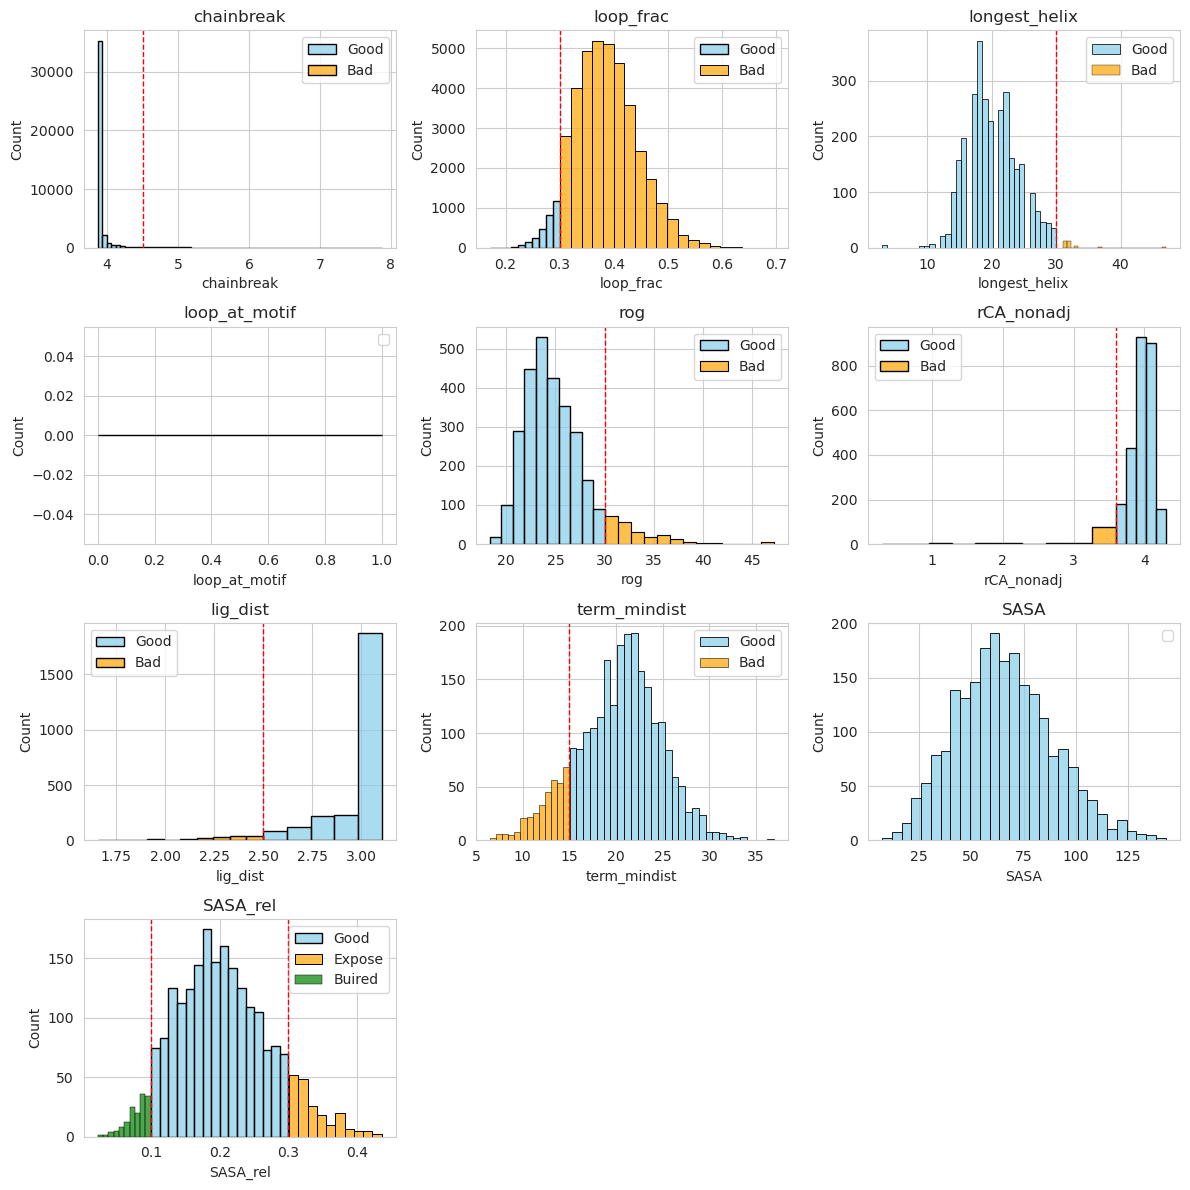

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read dataframe
dif_analysis_df = pd.read_csv(f"/data/liyunhao/Research/New_tSCA/diffusion_analysis/diffusion_analysis.sc", header=0, sep="\s+")

# Set Seaborn theme
sns.set_style("whitegrid")

plt.figure(figsize=(12, 12))
for i, k in enumerate(dif_analysis_df.keys()):
    if k in ["description"]:
        continue
    plt.subplot(4, 3, i+1)
    if k == "chainbreak":
        boundary_value = 4.5  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(dif_analysis_df[dif_analysis_df[k] <= boundary_value][k], bins=10, edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(dif_analysis_df[dif_analysis_df[k] > boundary_value][k], bins=5, edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    elif k == "loop_frac":
        boundary_value = 0.3  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(dif_analysis_df[dif_analysis_df[k] <= boundary_value][k], bins=10, edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(dif_analysis_df[dif_analysis_df[k] > boundary_value][k], bins=20, edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    elif k == "longest_helix":
        boundary_value = 30  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(dif_analysis_df[dif_analysis_df[k] <= boundary_value][k], edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(dif_analysis_df[dif_analysis_df[k] > boundary_value][k], edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    elif k == "rog":
        boundary_value = 30.0  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(dif_analysis_df[dif_analysis_df[k] <= boundary_value][k], bins=10, edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(dif_analysis_df[dif_analysis_df[k] > boundary_value][k], edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    elif k == "rCA_nonadj":
        boundary_value = 3.6  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(dif_analysis_df[dif_analysis_df[k] > boundary_value][k], bins=5, edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(dif_analysis_df[dif_analysis_df[k] <= boundary_value][k], bins=10, edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    elif k == "lig_dist":
        boundary_value = 2.5  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(dif_analysis_df[dif_analysis_df[k] > boundary_value][k], bins=5, edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(dif_analysis_df[dif_analysis_df[k] <= boundary_value][k], bins=10, edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    elif k == "term_mindist":
        boundary_value = 15.0  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(dif_analysis_df[dif_analysis_df[k] > boundary_value][k], edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(dif_analysis_df[dif_analysis_df[k] <= boundary_value][k], edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    elif k == "SASA_rel":
        boundary_value_1 = 0.3
        boundary_value_2 = 0.1

        # Creat masks to distinguish between different situations
        mask_good = (dif_analysis_df["SASA_rel"] <= boundary_value_1) & (dif_analysis_df["SASA_rel"] >= boundary_value_2)
        mask_bad_above_1 = dif_analysis_df["SASA_rel"] > boundary_value_1
        mask_bad_below_2 = dif_analysis_df["SASA_rel"] < boundary_value_2

        # Plot histograms
        sns.histplot(dif_analysis_df[mask_good]["SASA_rel"], edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        sns.histplot(dif_analysis_df[mask_bad_above_1]["SASA_rel"], edgecolor='black', kde=False, color='orange', alpha=0.7, label='Expose')
        sns.histplot(dif_analysis_df[mask_bad_below_2]["SASA_rel"], edgecolor='black', kde=False, color='green', alpha=0.7, label='Buired')

        # Add boundary line
        plt.axvline(x=boundary_value_1, color='red', linestyle='--', linewidth=1)
        plt.axvline(x=boundary_value_2, color='red', linestyle='--', linewidth=1)
    else:
        sns.histplot(dif_analysis_df[k], edgecolor='black', kde=False, color='skyblue', alpha=0.7)
    plt.title(k)
    plt.xlabel(k)
    plt.legend()

plt.tight_layout()
plt.savefig('/data/liyunhao/Research/New_tSCA/diffusion_analysis/diffusion_results.png', dpi=600)
plt.show()

### Step 2.3 Sequence Design of filtered diffusion scaffolds using ProteinMPNN
This step does not need to take into account the existence of ligand, the first task is to make the designed sequence can be folded into the specified shape.

In [ ]:
import glob
#First round of ProteinMPNN sequence design
diffused_backbones_good = glob.glob(f"/data/liyunhao/Research/New_tSCA/filtered_diffusion/*.pdb")
assert len(diffused_backbones_good) > 0, "No good backbones found!"
WDIR = "/data/liyunhao/Research/New_tSCA"
os.chdir(WDIR)

MPNN_DIR = f"{WDIR}/1_proteinmpnn"
os.makedirs(MPNN_DIR, exist_ok=True)
os.chdir(MPNN_DIR)

trb_file_path = "/data/liyunhao/Research/New_tSCA/cmd/trb_file_list.txt"
trb_file_list = "\n".join(d.replace(".pdb", ".trb") for d in diffused_backbones_good)
with open(trb_file_path, "w") as f:
    f.write(trb_file_list)

# Set the path to the JSONL file where masked positions are saved.
masked_pos_jsonl_path = "masked_pos.jsonl"

# Construct the command
mask_json_cmd = f"python /data/liyunhao/Research/New_tSCA/scripts/design/make_maskdict_from_trb.py --out masked_pos.jsonl --trblist {trb_file_path}"
print(mask_json_cmd)

python /data/liyunhao/Research/New_tSCA/scripts/design/make_maskdict_from_trb.py --out masked_pos.jsonl --trb $(>/data/liyunhao/Research/New_tSCA/cmd/trb_file_list.txt)


In [12]:
import glob

MPNN_temperatures = [0.1, 0.2, 0.3]
MPNN_outputs_per_temperature = 10
MPNN_omit_AAs = "CM"

commands_mpnn = []
diffusion_models = glob.glob("/data/liyunhao/Research/New_tSCA/filtered_diffusion/*.pdb")
cmds_filename_mpnn = "/data/liyunhao/Research/New_tSCA/cmd/commands_mpnn"
with open(cmds_filename_mpnn, "w") as file:
    for T in MPNN_temperatures:
        for f in diffusion_models:
            commands_mpnn.append(f"python /data/liyunhao/software/LigandMPNN/run.py "
                                 f"--model_type protein_mpnn --ligand_mpnn_use_atom_context 0 "
                                 f"--fixed_residues_multi /data/liyunhao/Research/New_tSCA/1_proteinmpnn/masked_pos.jsonl --out_folder /data/liyunhao/Research/New_tSCA/1_proteinmpnn/output_{T}  "
                                 f"--number_of_batches {MPNN_outputs_per_temperature} --temperature {T} "
                                 f"--omit_AA {MPNN_omit_AAs} --pdb_path {f} "
                                 f"--checkpoint_protein_mpnn /data/liyunhao/software/LigandMPNN/model_params/proteinmpnn_v_48_020.pt\n")
            file.write(commands_mpnn[-1])

print("Example MPNN command:")
print(commands_mpnn[-1])

Example MPNN command:
python /data/liyunhao/software/LigandMPNN/run.py --model_type protein_mpnn --ligand_mpnn_use_atom_context 0 --fixed_residues_multi /data/liyunhao/Research/New_tSCA/1_proteinmpnn/masked_pos.jsonl --out_folder /data/liyunhao/Research/New_tSCA/1_proteinmpnn/output_0.3  --number_of_batches 10 --temperature 0.3 --omit_AA CM --pdb_path /data/liyunhao/Research/New_tSCA/filtered_diffusion/Qsite_noZnH_dif_quadratic_1001_traj4.pdb --checkpoint_protein_mpnn /data/liyunhao/software/LigandMPNN/model_params/proteinmpnn_v_48_020.pt



In [ ]:
#Merge different temperature files
import os
import glob

# Soure folders
source_folders = [
    "/data/liyunhao/Research/New_tSCA/1_proteinmpnn/output_0.1/seqs/",
    "/data/liyunhao/Research/New_tSCA/1_proteinmpnn/output_0.2/seqs/",
    "/data/liyunhao/Research/New_tSCA/1_proteinmpnn/output_0.3/seqs/"
]

# Target folder
target_folder = "/data/liyunhao/Research/New_tSCA/1_proteinmpnn/output/"

# Name of the file to be merged
file_paths = glob.glob(f"/data/liyunhao/Research/New_tSCA/1_proteinmpnn/output_0.1/seqs/*.fa")
file_names = [os.path.basename(file_path) for file_path in file_paths]
print(file_names)
# Merge the files
for file_name in file_names:
    with open(os.path.join(target_folder, file_name), 'w') as merged_file:
        for folder in source_folders:
            file_path = os.path.join(folder, file_name)
            if os.path.exists(file_path):
                with open(file_path, 'r') as file:
                    merged_file.write(file.read())
                    merged_file.write('\n')  # Add line breaks between files to distinguish
                    print(file_name,' has been successfully merged!')

print("Files merged successfully!")

['Qsite_noZnH_dif_quadratic_917_traj2.fa', 'Qsite_noZnH_dif_quadratic_1522_traj3.fa', 'Qsite_noZnH_dif_quadratic_680_traj2.fa', 'Qsite_noZnH_dif_quadratic_1789_traj2.fa', 'Qsite_noZnH_dif_quadratic_1122_traj4.fa', 'Qsite_noZnH_dif_quadratic_1715.fa', 'Qsite_noZnH_dif_cubic_3630_traj4.fa', 'Qsite_noZnH_dif_quadratic_3288_traj4.fa', 'Qsite_noZnH_dif_cubic_1174_traj4.fa', 'Qsite_noZnH_dif_cubic_2326_traj1.fa', 'Qsite_noZnH_dif_quadratic_2296.fa', 'Qsite_noZnH_dif_quadratic_2770_traj1.fa', 'Qsite_noZnH_dif_cubic_2184_traj4.fa', 'Qsite_noZnH_dif_quadratic_453_traj3.fa', 'Qsite_noZnH_dif_quadratic_264_traj1.fa', 'Qsite_noZnH_dif_cubic_2873_traj2.fa', 'Qsite_noZnH_dif_cubic_2237.fa', 'Qsite_noZnH_dif_cubic_3458_traj1.fa', 'Qsite_noZnH_dif_quadratic_1560.fa', 'Qsite_noZnH_dif_quadratic_2539_traj3.fa', 'Qsite_noZnH_dif_quadratic_246_traj2.fa', 'Qsite_noZnH_dif_quadratic_1756_traj1.fa', 'Qsite_noZnH_dif_cubic_3463.fa', 'Qsite_noZnH_dif_quadratic_376_traj4.fa', 'Qsite_noZnH_dif_quadratic_3476_tra

### Step 2.4 Running AlphaFold2
Performing AF2 single sequence predictions

In [ ]:
#Alphafold 1st round, please see "Generalized biomolecular modeling and design with RoseTTAFold All-Atom" for more details. The "utils" component was derived directly from Dr. Indrek Kalvet's contributions.
import os
import sys
import glob
sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import utils

WDIR = '/data/liyunhao/Research/New_tSCA'
os.chdir(WDIR)

AF2_DIR = f"{WDIR}/2_af2"
os.makedirs(AF2_DIR, exist_ok=True)
os.chdir(AF2_DIR)

USE_GPU_for_AF2 = True

### First collecting MPNN outputs and creating FASTA files for AF2 input
mpnn_fasta = utils.parse_fasta_files(glob.glob(f"/data/liyunhao/Research/New_tSCA/1_proteinmpnn/output/*.fa"))
mpnn_fasta = {k: seq.strip() for k, seq in mpnn_fasta.items() if "model_path" not in k}  # excluding the diffused poly-A sequence
# Giving sequences unique names based on input PDB name, temperature, and sequence identifier
mpnn_fasta = {k.split(",")[0]+"_"+k.split(",")[2].replace(" T=", "T")+"_0_"+k.split(",")[1].replace(" id=", ""): seq for k, seq in mpnn_fasta.items()}

print(f"A total on {len(mpnn_fasta)} sequences will be predicted.")

## Splitting the MPNN sequences based on length
## and grouping them in smaller batches for each AF2 job
## Use group size of >40 when running on GPU. Also depends on how many sequences and resources you have.

SEQUENCES_PER_AF2_JOB = 5  # CPU
if USE_GPU_for_AF2 is True:
    SEQUENCES_PER_AF2_JOB = 200  # GPU
mpnn_fasta_split = utils.split_fasta_based_on_length(mpnn_fasta, SEQUENCES_PER_AF2_JOB, write_files=True)

A total on 54990 sequences will be predicted.
0 duplicate sequences removed.
Regrouping 122_5, 10 sequences
Regrouping 145_8, 10 sequences
Regrouping 153_8, 10 sequences
200 sequences of 149 length.
200 sequences of 149 length.
200 sequences of 149 length.
200 sequences of 149 length.
200 sequences of 149 length.
200 sequences of 149 length.
200 sequences of 149 length.
200 sequences of 149 length.
200 sequences of 149 length.
200 sequences of 111 length.
200 sequences of 111 length.
170 sequences of 111 length.
200 sequences of 136 length.
200 sequences of 136 length.
200 sequences of 136 length.
200 sequences of 136 length.
200 sequences of 136 length.
200 sequences of 136 length.
200 sequences of 136 length.
200 sequences of 136 length.
110 sequences of 136 length.
200 sequences of 146 length.
200 sequences of 146 length.
200 sequences of 146 length.
200 sequences of 146 length.
200 sequences of 146 length.
200 sequences of 146 length.
200 sequences of 146 length.
200 sequences of 1

In [1]:
import glob
## Setting up AlphaFold2 run

AF2_recycles = 8
AF2_models = "4"  # add other models to this string if needed
AF2_script = '/data/liyunhao/Research/New_tSCA/scripts/af2/af2.py'

commands_af2 = []
cmds_filename_af2 = "/data/liyunhao/Research/New_tSCA/cmd/commands_af2"
with open(cmds_filename_af2, "w") as file:
    for ff in glob.glob("/data/liyunhao/Research/New_tSCA/2_af2/*.fasta"):
        commands_af2.append(f"CUDA_VISIBLE_DEVICES=0 python {AF2_script} "
                             f"--af-nrecycles {AF2_recycles} --af-models {AF2_models} "
                             f"--fasta {ff} --scorefile {ff.replace('.fasta', '.csv')}\n")
        file.write(commands_af2[-1])

print("Example AF2 command:")
print(commands_af2[-1])

Example AF2 command:
CUDA_VISIBLE_DEVICES=0 python /data/liyunhao/Research/New_tSCA/scripts/af2/af2.py --af-nrecycles 8 --af-models 4 --fasta /data/liyunhao/Research/New_tSCA/2_af2/129aa_2.fasta --scorefile /data/liyunhao/Research/New_tSCA/2_af2/129aa_2.csv



In [2]:
import os
# Combining all CSV scorefiles into one
WDIR = '/data/liyunhao/Research/New_tSCA'
params = '/data/liyunhao/Research/New_tSCA/params/ACP.params'
os.chdir(WDIR)
AF2_DIR = f"{WDIR}/2_af2"
DIFFUSION_DIR = f"{WDIR}/0_diffusion"

os.system("head -n 1 /data/liyunhao/Research/New_tSCA/2_af2/score/110aa_0.csv > /data/liyunhao/Research/New_tSCA/2_af2/analysis/scores.csv ; for f in /data/liyunhao/Research/New_tSCA/2_af2/score/*aa*.csv ; do tail -n +2 ${f} >> /data/liyunhao/Research/New_tSCA/2_af2/analysis/scores.csv ; done")
assert os.path.exists("/data/liyunhao/Research/New_tSCA/2_af2/analysis/scores.csv"), "Could not combine scorefiles"

### Calculating the RMSDs of AF2 predictions relative to the diffusion outputs
### Catalytic residue sidechain RMSDs are calculated in the reference PDB has REMARK 666 line present

analysis_cmd = f"python /data/liyunhao/Research/New_tSCA/scripts/utils/analyze_af2.py --scorefile /data/liyunhao/Research/New_tSCA/2_af2/analysis/scores.csv "\
               f"--ref_path /data/liyunhao/Research/New_tSCA/filtered_diffusion/ --mpnn --params {params} > /data/liyunhao/Research/New_tSCA/log/analyze_af2_ACP.log"
print(analysis_cmd)

python /data/liyunhao/Research/New_tSCA/scripts/utils/analyze_af2.py --scorefile /data/liyunhao/Research/New_tSCA/2_af2/analysis/scores.csv --ref_path /data/liyunhao/Research/New_tSCA/filtered_diffusion/ --mpnn --params /data/liyunhao/Research/New_tSCA/params/ACP.params > /data/liyunhao/Research/New_tSCA/log/analyze_af2_ACP.log


lDDT                     >=  85.000: 4336 items left. 4336 pass (8%).
rmsd                     <=   1.500: 637 items left. 1002 pass (2%).
rmsd_SR3                 <=   2.000: 104 items left. 810 pass (1%).


/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na opti

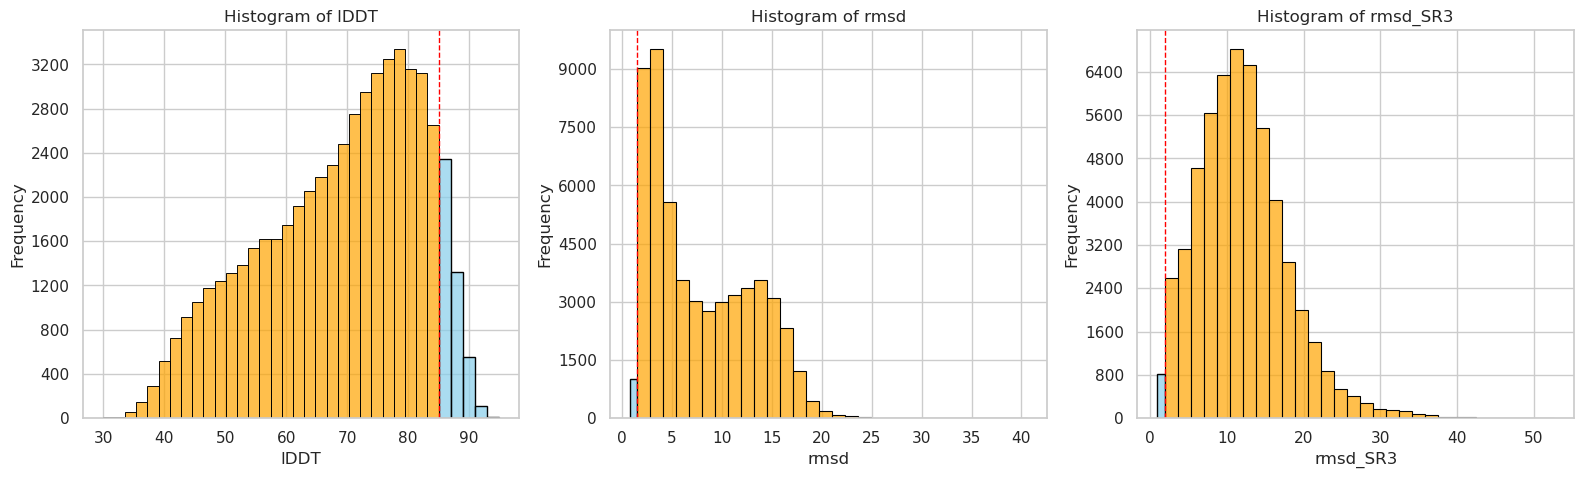

/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/liyunhao/mambaforge/envs/RFDiffAA/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


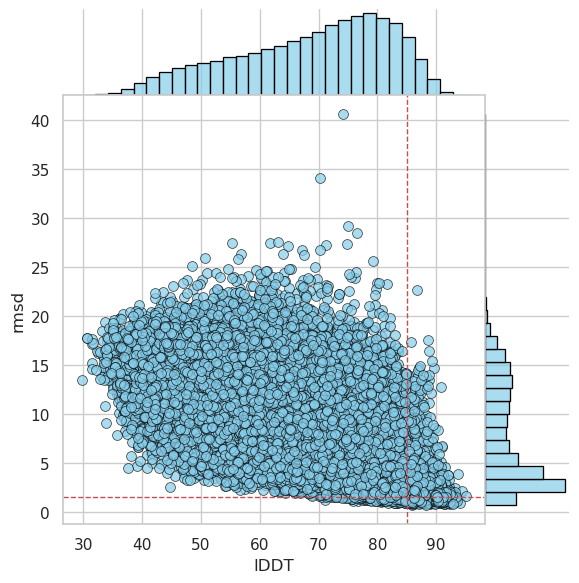

In [ ]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import utils

# Set Seaborn theme
sns.set(style="whitegrid")

# Read dataframe
scores_af2 = pd.read_csv("/data/liyunhao/Research/New_tSCA/2_af2/analysis/scores.sc", sep="\s+", header=0)

# Define filter matrix. Here rmsd_SR3 refers to the sidechain RMSD of retained Glu residue.
AF2_filters = {"lDDT": [85.0, ">="],
               "rmsd": [1.5, "<="],
               "rmsd_SR3": [2.0, "<="]}

# Filter the data
scores_af2_filtered = utils.filter_scores(scores_af2, AF2_filters)

# Save filtered data
utils.dump_scorefile(scores_af2_filtered, "/data/liyunhao/Research/New_tSCA/2_af2/analysis/filtered_scores_ACP.sc")

# Plot the histogram 
plt.figure(figsize=(16, 9))
for i, k in enumerate(AF2_filters):
    plt.subplot(2, 3, i+1)
    # 绘制柱状图并添加描边
    #bars = plt.hist(scores_af2[k], bins=30, edgecolor='black', color='skyblue', alpha=0.7)
    plt.title(f'Histogram of {k}')
    plt.xlabel(k)
    plt.ylabel('Frequency')
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))  # Ensure that the y-axis scale is an integer
    if k == "lDDT":
        boundary_value = 85.0  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(scores_af2[scores_af2[k] >= boundary_value][k], bins=5, edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(scores_af2[scores_af2[k] < boundary_value][k], bins=30, edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    if k == "rmsd":
        boundary_value = 1.5  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(scores_af2[scores_af2[k] <= boundary_value][k], bins=1, edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(scores_af2[scores_af2[k] > boundary_value][k], bins=30, edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
    if k == "rmsd_SR3":
        boundary_value = 2.0  # Set boundary_value
        # Plot the histogram to the left of the boundary line and set the colour to skyblue
        sns.histplot(scores_af2[scores_af2[k] <= boundary_value][k], bins=1, edgecolor='black', kde=False, color='skyblue', alpha=0.7, label='Good')
        # Plot the histogram to the right of the boundary line and set the colour to orange
        sns.histplot(scores_af2[scores_af2[k] > boundary_value][k], bins=30, edgecolor='black', kde=False, color='orange', alpha=0.7, label='Bad')
        plt.axvline(x=boundary_value, color='red', linestyle='--', linewidth=1)  # Add boundary line
plt.tight_layout()
plt.show()

# Plot scatterplots with edge histograms
def plot_score_pairs_with_marginals(df, x_col, y_col, x_cutoff, y_cutoff):
    g = sns.JointGrid(data=df, x=x_col, y=y_col, space=0, ratio=5)
    g.plot_joint(sns.scatterplot, edgecolor="black", color='skyblue', s=50, alpha=0.7)
    g.plot_marginals(sns.histplot, kde=False, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
    g.ax_joint.axhline(y=y_cutoff, color='r', linestyle='--', linewidth=1)
    g.ax_joint.axvline(x=x_cutoff, color='r', linestyle='--', linewidth=1)
    g.set_axis_labels(x_col, y_col)
    g.ax_joint.set_title(f'Scatter plot of {x_col} vs {y_col} with marginals')
    g.ax_joint.tick_params(axis='x', direction='out')
    g.ax_joint.tick_params(axis='y', direction='out')
    plt.show()

plot_score_pairs_with_marginals(scores_af2, "lDDT", "rmsd", AF2_filters["lDDT"][0], AF2_filters["rmsd"][0])

In [ ]:
# Copying good predictions to a separate directory
from shutil import copy2
import os
import subprocess
import glob
WDIR = '/data/liyunhao/Research/New_tSCA'
params = '/data/liyunhao/Research/New_tSCA/params/ACP.params'
AF2_DIR = f"{WDIR}/2_af2"
OUT_DIR = f"{AF2_DIR}/output"
os.chdir(OUT_DIR)

if len(scores_af2_filtered) > 0:
    os.makedirs("good", exist_ok=True)
    good_af2_models = [row["Output_PDB"]+".pdb" for idx,row in scores_af2_filtered.iterrows()]
    for pdb in good_af2_models:
        copy2(pdb, f"good/{pdb}")
    good_af2_models = glob.glob(f"{AF2_DIR}/good/*.pdb")
else:
    sys.exit("No good models to continue this pipeline with")

os.chdir(f"{AF2_DIR}/good")


In [ ]:
# Add Matchlines for good predictions.
python place_matcher_lines.py --pdb /data/liyunhao/Research/New_tSCA/2_af2/good --params /data/liyunhao/Research/New_tSCA/params/ACP.params --ref /data/liyunhao/Research/New_tSCA/filtered_diffusion --outdir /data/liyunhao/Research/New_tSCA/2_af2/match_lines --fix_catres

## Step 3. Ligand docking and metal adding
This step focuses on ligand docking and the addition of metal ions

### Step 3.1 RIFDock of acetophenone
We have tried to directly align the results of RFDiffusionAA directly to the structure predicted by AF2, but too many collisions will have a large impact on the subsequent process. After many attempts, it would be better to redock acetophenone into the structure via RIFDock.

In [ ]:
# RIFGEN command
$RIFDOCK/rifgen @rifgen_ACP.flags > rifgen.log 

In [ ]:
# This block is used to get Thr residue numbers which will be used as pos file in RIFDock.
import glob
import os

# Get PDB file path, the input folder is the output of adding match lines.
pdb_files = glob.glob('/data2/liyunhao/New_tSCA/RifDock/input/*.pdb')

# Output path
pos_output_path = "/data2/liyunhao/New_tSCA/RifDock/pose/"

for pdb in pdb_files:
    # Get the PDB filename and remove the extension
    pdb_name = os.path.basename(pdb).replace('.pdb', '')
    thr_number = []  # Used to store the extracted Thr residue numbers
    
    # Read PDB files
    with open(pdb, 'r') as read_f:
        for line in read_f:
            # Checks if the line contains the specified string
            if 'REMARK 666 MATCH TEMPLATE X ACP    0 MATCH MOTIF A THR' in line:
                # Split the row and extract the penultimate element as the Thr res number
                parts = line.split()
                thr_number.append(int(parts[-3]))

    # Write the extracted Thr res numbers to the .pos file
    with open(f'{pos_output_path}{pdb_name}.pos', 'a+') as output_f:
        for num in thr_number:
            output_f.write(f"{num} ")


In [ ]:
# RIFDock command generation
import glob
import os

# Get PDB file path
pdb_files = glob.glob('/data2/liyunhao/New_tSCA/RifDock/input/*.pdb')

# Define output path
pos_output_path = "/data2/liyunhao/New_tSCA/RifDock/pose/"
rifdock = '/home/liyunhao/rosetta_src_2018.09.60072_bundle/main/source/rifdock/build/apps/rosetta/rif_dock_test'
flag = '/data2/liyunhao/New_tSCA/RifDock/flags/rifdock_ACP_1.flags'

"""/home/liyunhao/rosetta_src_2018.09.60072_bundle/main/source/rifdock/build/apps/rosetta/rif_dock_test 
@/data2/liyunhao/RhP/RifDock/flags/rifdock_DPA_1.flags 
-scaffolds /data2/liyunhao/RhP/RifDock/input/d3area1_model_22_T0.1_0_3_model_4.0_r8_af2_0001.pdb 
-scaffold_res /data2/liyunhao/RhP/RifDock/input/d3area1_model_22_T0.1_0_3_model_4.0_r8_af2_0001.pdb_1.pos"""

for pdb in pdb_files:
    pdb_name = os.path.basename(pdb).replace('.pdb', '')
    with open('/data2/liyunhao/New_tSCA/RifDock/cmd/rifdock_cmd.txt','a+') as output:
        output.write(f'{rifdock} @{flag} -scaffolds {pdb} -scaffold_res {pos_output_path}{pdb_name}.pos\n')
        
# Submit commands on your own way

### Step 3.2 Quick design protocols
After RIFDock, the ligand was docked into protein scaffolds. However, there were some bad dock results, which need to be filtered in advance, otherwise it would subsequently cause a large amount of wasted computing resources.

In [ ]:
#Copy the results of Rifdock to the Quick Design folder
find /data2/liyunhao/New_tSCA/RifDock/output/ -type f -name "*.pdb.gz" -exec cp {} /data2/liyunhao/New_tSCA/quick_design/input \;
gunzip *.gz

In [ ]:
# Add matchlines to RIF results
import os
import glob

rif_results = glob.glob('/data2/liyunhao/New_tSCA/quick_design/input/*.pdb')
ref_folder = '/data2/liyunhao/New_tSCA/RifDock/input/'

for rif_pdb in rif_results:
    rif_name = os.path.basename(rif_pdb).replace('.pdb', '')
    base_name_split = rif_name.split('_')[:-1]
    base_name = '_'.join(base_name_split)
    remark_lines = [] 
    
    with open(f'{ref_folder}{base_name}.pdb','r+') as f_read:
        for line in f_read:
            # Checks if the line contains the specified string
            if 'REMARK 666 MATCH TEMPLATE X ACP    0 MATCH MOTIF A' in line:
                remark_lines.append(line)  # Save remark lines
    # Read the contents of the target PDB file
    
    with open(rif_pdb, 'r') as f_out_read:
        original_content = f_out_read.readlines()  # Read the original content

    # Add the remark line to the beginning of the file
    new_content = remark_lines + original_content

    # Write the modified content back to the target PDB file
    with open(rif_pdb, 'w') as f_out_write:
        f_out_write.writelines(new_content)  # Write back new content

In [ ]:
# Quick design command generation
import pyrosetta
import pyrosetta.distributed.io
sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import design_utils
import glob
import os
from pyrosetta import *

pdb_files = glob.glob('/data2/liyunhao/New_tSCA/quick_design/input/*.pdb')
cmd_path = '/data2/liyunhao/New_tSCA/quick_design/cmd/'
rosetta_path = '/home/liyunhao/Rosetta/main/source/bin/rosetta_scripts.mpi.linuxgccrelease'
flags = '/data2/liyunhao/New_tSCA/quick_design/scripts/quick_design.flags'
init('-extra_res_fa /data2/liyunhao/New_tSCA/quick_design/params/ACP.params')

"""/home/liyunhao/Rosetta/main/source/bin/rosetta_scripts.mpi.linuxgccrelease 
@/data2/liyunhao/New_tSCA/quick_design/scripts/quick_design.flags 
-s /data2/liyunhao/New_tSCA/quick_design/input/Qsite_noZnH_dif_cubic_404_T0.2_0_7_model_4.0_r8_af2_000000000.pdb 
-parser:script_vars lig_res=145 cat_res=34,36,46,57,95,96"""

for pdb in pdb_files:
    input_pose = pyrosetta.pose_from_file(pdb)
    pose = input_pose.clone()

    # Storing REMARK 666 lines from input pose to keep the catalytic residue information
    remarks = [l for l in pyrosetta.distributed.io.to_pdbstring(pose).split("\n") if "REMARK 666" in l]

    ligand_resno = pose.size()
    assert pose.residue(ligand_resno).is_ligand()

    matched_residues = design_utils.get_matcher_residues(pdb)
    catalytic_resnos = list(matched_residues.keys())
    cat_res = ','.join(map(str, catalytic_resnos))
    with open(f'{cmd_path}quick_design.txt','a+') as f_out:
        f_out.write(f'{rosetta_path} @{flags} -s {pdb} -parser:script_vars lig_res={ligand_resno} cat_res={cat_res}\n')

# Submit commands on your own way

In [ ]:
# Analysis data and save it to a excel file
import pandas as pd

# Read data
with open('/data2/liyunhao/New_tSCA/quick_design/score/score.sc', 'r') as file:
    data = file.read()

# Split data into rows
lines = data.strip().split('\n')

# Separation of header and data
header = lines[1].split()  # The second row is the header
rows = [line.split() for line in lines[2:]]  # The third and subsequent rows are data

# Creat DataFrame
df = pd.DataFrame(rows, columns=header)

selected_columns = ['total_score', 'O1_hbond_fil', 'contact_molecular_surface', 'ddg_norepack', 'dsasa','description']

# Extract the columns you need
df_selected = df[selected_columns]

# Save results to an Excel file
output_path = '/data2/liyunhao/New_tSCA/quick_design/analysis/selected_scores.xlsx'
df_selected.to_excel(output_path, index=False)

print(f'Data has been saved to the {output_path}')


In [ ]:
#Draw a picture to view it more visually
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the data and remove the SEQUENCE: line
file_path = '/data2/liyunhao/New_tSCA/quick_design/score/score.sc'

# Read the contents of the file first
with open(file_path, 'r') as file:
    lines = file.readlines()

# Remove the SEQUENCE: line.
lines = [line for line in lines if not line.startswith("SEQUENCE:")]

# Write the results to a temporary file
temp_file_path = '/data2/liyunhao/New_tSCA/quick_design/score/temp_FastPredictor2_ACP.sc'
with open(temp_file_path, 'w') as temp_file:
    temp_file.writelines(lines)

# Read data in CSV format
df = pd.read_csv(temp_file_path, delim_whitespace=True, header=0)

# Extract multiple columns
columns_to_extract = ['contact_molecular_surface', 'ddg_norepack', 'dsasa', 'O1_hbond_fil']
cms_data = df[columns_to_extract]

# Set colours
colors = ['#EEA599', '#FFE9BE', '#ABD3E1', '#D0B4E2']

# Creat a Subgraph Layout
num_columns = len(columns_to_extract)
num_rows = (num_columns + 1) // 2  # two-column layout

fig, axs = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, 6 * num_rows))
axs = axs.flatten()  # Flatten subgraphs for easy indexing

# Plot histograms and medians for each column
for ax, column, color in zip(axs, columns_to_extract, colors):
    # Extract data
    data = cms_data[column]
    
    # Calculate the median
    median_value = data.median()
    
    # Plot histograms
    sns.histplot(data, bins=30, kde=True, ax=ax, color=color)
    
    # Plot the median line
    ax.axvline(median_value, color='red', linestyle='--', label=f'Median: {median_value:.2f}')
    
    # Add title and tags
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    
    # Show legend
    ax.legend()

# Hide unused subgraphs
for i in range(len(columns_to_extract), len(axs)):
    fig.delaxes(axs[i])

# Restructuring of the layout
plt.tight_layout()

# Svae fig
plt.savefig('/data2/liyunhao/New_tSCA/quick_design/analysis/quick_all_distributions.png', dpi=600, transparent=True)

# Show fig
plt.show()


In [ ]:
# Filter quick design results
import os
import pandas as pd
import shutil

# Read the data and remove the SEQUENCE: line
file_path = '/data2/liyunhao/New_tSCA/quick_design/score/score.sc'

# Read the contents of the file first
with open(file_path, 'r') as file:
    lines = file.readlines()

# Remove the SEQUENCE: line.
lines = [line for line in lines if not line.startswith("SEQUENCE:")]

# Write the results to a temporary file
temp_file_path = '/data2/liyunhao/New_tSCA/quick_design/score/temp_FastPredictor2_ACP.sc'
with open(temp_file_path, 'w') as temp_file:
    temp_file.writelines(lines)

# Read data in CSV format
df = pd.read_csv(temp_file_path, delim_whitespace=True, header=0)

# Filter matrix
conditions = {
    'contact_molecular_surface': df['contact_molecular_surface'] >= 120,
    'ddg_norepack': df['ddg_norepack'] <= -10,
    'dsasa': (df['dsasa'] >= 0.80) & (df['dsasa'] <= 0.95),
    'O8_hbond_fil': df['O1_hbond_fil'] >= 1
}

# Calculate the number of filters for each condition
filtered_df = df.copy()
for key, condition in conditions.items():
    filtered_count = filtered_df[condition].shape[0]
    print(f"{key} condition: {filtered_count} structures passed.")
    filtered_df = filtered_df[condition]

# Number of final screenings
total_passed = filtered_df.shape[0]
print(f"Total structures passed: {total_passed} out of {df.shape[0]}, which is {total_passed / df.shape[0] * 100:.2f}%.")

# Copy the filtered PDB files to a new folder
output_dir = '/data2/liyunhao/New_tSCA/quick_design/filtered/'
os.makedirs(output_dir, exist_ok=True)

for description in filtered_df['description']:
    pdb_file = os.path.join('/data2/liyunhao/New_tSCA/quick_design/output/', f"{description}.pdb")
    shutil.copy(pdb_file, output_dir)

print(f"Filtered PDB files copied to {output_dir}.")


### Step 3.3 Constraint Relax
In this step, we will use FastRelax module in Rosetta with constraints to relax the structure so that the 3 retained His can retain essentially the correct conformation to accurately predict the presence of zinc ions in the subsequent steps.

In [ ]:
# Command generation stage, The "design_utils" module is based on the code of "Generalized biomolecular modeling and design with RoseTTAFold All-Atom".
import pyrosetta
import pyrosetta.distributed.io
sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import design_utils
import glob
import os
from pyrosetta import *

pdb_files = glob.glob('/data2/liyunhao/New_tSCA/Constraint_relax/input/*.pdb')
cmd_path = '/data2/liyunhao/New_tSCA/Constraint_relax/cmd/'
rosetta_path = '/home/liyunhao/Rosetta/main/source/bin/rosetta_scripts.mpi.linuxgccrelease'
cst_path = '/data2/liyunhao/New_tSCA/Constraint_relax/cst/'
flags = '/data2/liyunhao/New_tSCA/Constraint_relax/scripts/cst_relax.flags'
init('-extra_res_fa /data2/liyunhao/New_tSCA/quick_design/params/ACP.params')

"""
/home/liyunhao/Rosetta/main/source/bin/rosetta_scripts.mpi.linuxgccrelease 
@/data2/liyunhao/Zinc_enzyme/Constraint_Relax/scripts/cst_relax.flags 
-s /data2/liyunhao/Zinc_enzyme/Constraint_Relax/input/test2_2574_20_0001_000000007.pdb 
-parser:script_vars cst_file=/data2/liyunhao/Zinc_enzyme/Constraint_Relax/cst_file/test2_2574_20_0001_000000007.cst
"""

for pdb in pdb_files:
    pdb_name = os.path.basename(pdb).replace('.pdb', '')
    input_pose = pyrosetta.pose_from_file(pdb)
    pose = input_pose.clone()

    # Storing REMARK 666 lines from input pose to keep the catalytic residue information
    remarks = [l for l in pyrosetta.distributed.io.to_pdbstring(pose).split("\n") if "REMARK 666" in l]

    ligand_resno = pose.size()
    assert pose.residue(ligand_resno).is_ligand()

    matched_residues = design_utils.get_matcher_residues(pdb)
    catalytic_resnos = list(matched_residues.keys())
    cat_res = ','.join(map(str, catalytic_resnos))
    
    with open(f'{cst_path}{pdb_name}.cst','a+') as cst_file:
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[0]}A  NE2 {catalytic_resnos[1]}A HARMONIC 3.12 0.1\n")
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[0]}A  ND1 {catalytic_resnos[3]}A HARMONIC 3.43 0.1\n")
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[1]}A  ND1 {catalytic_resnos[3]}A HARMONIC 3.15 0.1\n")
    
    with open(f'{cmd_path}cst_realx.txt', 'a+') as cmd_file:
        cmd_file.write(f'{rosetta_path} @{flags} -s {pdb} -parser:script_vars cst_file={cst_path}{pdb_name}.cst\n')

# Submit command on your way.

### Step 3.4 Metal site prediction
Predict the position of zinc ions using Metal3D

In [ ]:
# Command generation stage
import os

path_to_output_cmd = "/data/liyunhao/Research/New_tSCA/cmd/predictcmd.txt"
pdb_folder = "/data/liyunhao/Research/New_tSCA/metal_docking/input/"
path_to_predict = "/data/liyunhao/software/Metal3D/metal-site-prediction-main/Metal3D/metal3d.py"

"""python /data/liyunhao/software/Metal3D/metal-site-prediction-main/Metal3D/metal3d.py --pdb 
/data/liyunhao/Research/Small_CA/metal_docking/input/test2_977_6.pdb --metalbinding --writeprobes --probefile metalsites.pdb --maxp"""

with open(path_to_output_cmd, 'a') as output_file:
    for pdb_file in os.listdir(pdb_folder):
        pdb_file_name = os.path.splitext(pdb_file)[0]
        output_file.write("python " + path_to_predict + " --pdb " + pdb_folder + pdb_file + \
            " --metalbinding --writeprobes --probefile " +  pdb_file_name + "_Zn.pdb --maxp" + "\n")
        
# Submit command on your own way

In [ ]:
# This block combines the prediction zinc pdb file with orginal pdb file.
import os
import shutil

# Specify the paths of the two original folders and the path of the new folder
folder1_path = '/data/liyunhao/Research/New_tSCA/metal_docking/input'  # folder_1
folder2_path = '/data/liyunhao/Research/New_tSCA/metal_docking/output'  # folder_2
output_folder_path = '/data/liyunhao/Research/New_tSCA/metal_docking/combined'  # combined output folder

# mkdir
if not os.path.exists(output_folder_path):
    os.mkdir(output_folder_path)

# Get the name of the file in the first folder
folder1_files = os.listdir(folder1_path)

# Loop over the files in the first folder
for file1 in folder1_files:
    # Construct the second filename associated with the first filename
    file2 = file1.replace('.pdb', '_Zn.pdb')

    # Check if the second file exists in the second folder
    if os.path.exists(os.path.join(folder2_path, file2)):
        # Merge the contents of two files
        with open(os.path.join(folder1_path, file1), 'r') as f1, open(os.path.join(folder2_path, file2), 'r') as f2:
            content1 = f1.read()
            content2 = f2.read()

        # Find the location of the "TER" line in the first file.
        index_of_ter = content1.find("TER")
        index_of_ter2 = content1.find("TER", index_of_ter+1)
        
        if index_of_ter2 != -1:
            # After inserting the contents of the second file into the TER line position
            merged_content = content1[:index_of_ter2] +  content2 + content1[index_of_ter2:]
        else:
            # If you can't find the "TER" line, add the contents of the second file directly to the end of the merged file.
            merged_content = content1 + "\nTER\n" + content2

        # Save the merged contents to a new folder
        merged_file_path = os.path.join(output_folder_path, file1)
        with open(merged_file_path, 'w') as merged_file:
            merged_file.write(merged_content)

# Output
print("PDB file merge complete!")


In [ ]:
# This block process merged PDB files, a merged file may contain multiple Zn sites.
import os

# Function for processing a single PDB file
def process_pdb_file(input_file, output_folder):
    with open(input_file, 'r') as f:
        lines = f.readlines()
        acp_list = []
    # Find HETNAM line and insert new HETNAM
    for i, line in enumerate(lines):
        if line.startswith("HETNAM     ACP B"):
            acp_list = line.split()
            lines.insert(i + 1, "HETNAM     ZN1 X " + str(int(acp_list[3])+1) + "  ZN1" + "\n")
            break

    # Find HETATM lines and process them
    zinc_lines = []
    max_occupancy = 0
    max_occupancy_line = None  # initialize max_occupancy_line

    i = 0
    while i < len(lines):
        line = lines[i]

        if line.endswith("ZN2+\n"):
            parts = line.split()
            occupancy = float(parts[9])

            if occupancy > max_occupancy:
                max_occupancy = occupancy
                max_occupancy_line = line

            zinc_lines.append(line)
            i += 1
        else:
            i += 1

    # Delete HETATM lines other than max_occupancy_line
    for line in zinc_lines:
        if line != max_occupancy_line:
            lines.remove(line)
            
    max_atom_number = 0
    
    for i in range(len(lines)):
        if lines[i].startswith('HETATM'):
            parts = lines[i].split()
            try:
                atom_number = int(parts[1])
                if atom_number > max_atom_number:
                    max_atom_number = atom_number
            except ValueError:
                continue
            # Replace the number after HETATM with atom_count
        if lines[i].endswith("ZN2+\n"):
            parts[1] = str(max_atom_number+1)
            parts[2] = "ZN1"
            parts[3] = "ZN1"
            parts[4] = "X"
            # Replace the number after A with residue_count
            parts[5] = str(int(acp_list[3])+1)
            # Change theoccupation section to 1.00 and make sure it is aligned correctly
            parts[-3] = '1.00'
            parts[-2] = '0.00'
            # Reconstruct rows to ensure column alignment
            new_line = '{:<6}{:>5} {:>3}  {:>3}{:>2}{:>4}    {:>8}{:>8}{:>8}{:>6}{:>6}          {:>2}\n'.format(*parts)
            lines[i] = new_line
            
    # Creat a new file path and filename
    output_filename = os.path.basename(input_file)
    output_filepath = os.path.join(output_folder, output_filename)

    # Write processed PDB data to a new file
    with open(output_filepath, 'w') as f:
        f.writelines(lines)

# Input folder and output folder
input_folder = "/data/liyunhao/Research/New_tSCA/metal_docking/combined"
output_folder = "/data/liyunhao/Research/New_tSCA/metal_docking/process"

# Creat an output folder
os.makedirs(output_folder, exist_ok=True)

# Handle folders containing PDB files
for filename in os.listdir(input_folder):
    if filename.endswith(".pdb"):
        input_file = os.path.join(input_folder, filename)
        process_pdb_file(input_file, output_folder)


## Step 4. Sequence Design
This step will perform the sequence design.

### Step 4.1 RosettaDesign
We performed multiple rounds of FastDesign to optimize the interaction between ligand and protein. Additionally, strong constraint was applied to Zn-His and Zn-ligand to ensure correct conformation during design stage.

In [ ]:
# Command generation stage
import pyrosetta
import pyrosetta.distributed.io
sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import design_utils
import glob
import os
from pyrosetta import *

pdb_files = glob.glob('/data2/liyunhao/New_tSCA/RosettaDesign/input/*.pdb')
cmd_path = '/data2/liyunhao/New_tSCA/RosettaDesign/cmd/'
rosetta_path = '/home/liyunhao/Rosetta/main/source/bin/rosetta_scripts.mpi.linuxgccrelease'
cst_path = '/data2/liyunhao/New_tSCA/RosettaDesign/cst/'
flags = '/data2/liyunhao/New_tSCA/RosettaDesign/flags/design.flags'
init('-extra_res_fa /data2/liyunhao/New_tSCA/RosettaDesign/params/ACP.params /data2/liyunhao/New_tSCA/RosettaDesign/params/ZN1.params')

""" /home/liyunhao/Rosetta/main/source/bin/rosetta_scripts.mpi.linuxgccrelease 
@/data2/liyunhao/Zinc_enzyme/RosettaDesign/flags/design.flags 
-s /data2/liyunhao/Zinc_enzyme/RosettaDesign/input/test2_2660_27_0001_000000001_0001.pdb 
-parser:script_vars lig_res=143 cat_res=51,53,59,67,92 cst_file=/data2/liyunhao/Zinc_enzyme/RosettaDesign/cst/test2_2660_27_0001_000000001_0001.cst"""

for pdb in pdb_files:
    pdb_name = os.path.basename(pdb).replace('.pdb', '')
    input_pose = pyrosetta.pose_from_file(pdb)
    pose = input_pose.clone()

    # Storing REMARK 666 lines from input pose to keep the catalytic residue information
    remarks = [l for l in pyrosetta.distributed.io.to_pdbstring(pose).split("\n") if "REMARK 666" in l]
    
    zn_resno = pose.size()
    ligand_resno = pose.size() - 1
    assert pose.residue(ligand_resno).is_ligand()

    matched_residues = design_utils.get_matcher_residues(pdb)
    catalytic_resnos = list(matched_residues.keys())
    cat_res = ','.join(map(str, catalytic_resnos))
    
    # Cst file generation part
    with open(f'{cst_path}{pdb_name}.cst','a+') as cst_file:
        # Distance constraint of Nhis atoms
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[0]}A  NE2 {catalytic_resnos[1]}A HARMONIC 3.12 0.1\n")
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[0]}A  ND1 {catalytic_resnos[3]}A HARMONIC 3.43 0.1\n")
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[1]}A  ND1 {catalytic_resnos[3]}A HARMONIC 3.15 0.1\n")
        # Distance constraint of Zn and Nhis atoms
        cst_file.write(f"AtomPair ZN1 {zn_resno}X  NE2 {catalytic_resnos[0]}A HARMONIC 2.17 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}X  NE2 {catalytic_resnos[1]}A HARMONIC 2.11 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}X  ND1 {catalytic_resnos[3]}A HARMONIC 2.12 0.1\n")
        # Angle constatint of Zn and His
        cst_file.write(f"Angle ZN1 {zn_resno}X NE2 {catalytic_resnos[0]}A CD2 {catalytic_resnos[0]}A CIRCULARHARMONIC 2.089 0.1\n")
        cst_file.write(f"Angle ZN1 {zn_resno}X NE2 {catalytic_resnos[1]}A CD2 {catalytic_resnos[1]}A CIRCULARHARMONIC 2.126 0.1\n")
        cst_file.write(f"Angle ZN1 {zn_resno}X ND1 {catalytic_resnos[3]}A CE1 {catalytic_resnos[3]}A CIRCULARHARMONIC 1.881 0.1\n")
        # Dihedral constarint of Zn and His
        cst_file.write(f"Dihedral ZN1 {zn_resno}X NE2 {catalytic_resnos[0]}A CD2 {catalytic_resnos[0]}A CG {catalytic_resnos[0]}A CIRCULARHARMONIC 3.028 0.1\n")
        cst_file.write(f"Dihedral ZN1 {zn_resno}X NE2 {catalytic_resnos[1]}A CD2 {catalytic_resnos[1]}A CG {catalytic_resnos[1]}A CIRCULARHARMONIC -2.994 0.1\n")
        cst_file.write(f"Dihedral ZN1 {zn_resno}X ND1 {catalytic_resnos[3]}A CE1 {catalytic_resnos[3]}A NE2 {catalytic_resnos[3]}A CIRCULARHARMONIC -2.969 0.1\n")
        # Distance constraint of Zn and ligand
        cst_file.write(f"AtomPair ZN1 {zn_resno}X C7 {ligand_resno}B HARMONIC 4.59 0.5\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}X O1 {ligand_resno}B HARMONIC 4.69 0.5\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}X CA {catalytic_resnos[0]}A HARMONIC 6.37 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}X CA {catalytic_resnos[1]}A HARMONIC 6.60 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}X CA {catalytic_resnos[3]}A HARMONIC 5.44 0.1\n")
    
    with open(f'{cmd_path}design_cmd.txt', 'a+') as cmd_file:
        cmd_file.write(f'{rosetta_path} @{flags} -s {pdb} -parser:script_vars lig_res={ligand_resno} cat_res={cat_res} cst_file={cst_path}{pdb_name}.cst\n')

# Submit command on your own way

In [ ]:
# Analysis of RosettaDesign score
import pandas as pd

# Read data
with open('/data2/liyunhao/New_tSCA/RosettaDesign/score/score.sc', 'r') as file:
    data = file.read()

# Split data into rows
lines = data.strip().split('\n')

# Separation of header and data
header = lines[1].split()
rows = [line.split() for line in lines[2:]]

# Create DataFrame
df = pd.DataFrame(rows, columns=header)

# Delete "SCORE"
df.drop(columns=["SCORE:"], inplace=True)
df.drop(columns=["angle_constraint"], inplace=True)
df.drop(columns=["atom_pair_constraint"], inplace=True)
df.drop(columns=["cart_bonded"], inplace=True)
df.drop(columns=["coordinate_constraint"], inplace=True)
df.drop(columns=["dihedral_constraint"], inplace=True)
df.drop(columns=["dslf_fa13"], inplace=True)
df.drop(columns=["fa_atr"], inplace=True)
df.drop(columns=["fa_dun"], inplace=True)
df.drop(columns=["fa_elec"], inplace=True)
df.drop(columns=["fa_intra_rep"], inplace=True)
df.drop(columns=["fa_intra_sol_xover4"], inplace=True)
df.drop(columns=["fa_rep"], inplace=True)
df.drop(columns=["fa_sol"], inplace=True)
df.drop(columns=["hbond_bb_sc"], inplace=True)
df.drop(columns=["hbond_lr_bb"], inplace=True)
df.drop(columns=["hbond_sc"], inplace=True)
df.drop(columns=["hbond_sr_bb"], inplace=True)
df.drop(columns=["lk_ball_wtd"], inplace=True)
df.drop(columns=["omega"], inplace=True)
df.drop(columns=["p_aa_pp"], inplace=True)
df.drop(columns=["rama_prepro"], inplace=True)
df.drop(columns=["ref"], inplace=True)
df.drop(columns=["res_type_constraint"], inplace=True)
df.drop(columns=["yhh_planarity"], inplace=True)


# Move the "description" column to the first column
cols = df.columns.tolist()
cols = [cols[-1]] + cols[:-1]
df = df[cols]

# Save as Excel file
excel_file = '/data2/liyunhao/New_tSCA/RosettaDesign/analysis/tSCA_Design.xlsx'
df.to_excel(excel_file, index=False)

print(f"The data has been saved as {excel_file}")


In [ ]:
# Plot design score results
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the data and remove the SEQUENCE: line
file_path = '/data2/liyunhao/New_tSCA/RosettaDesign/score/score.sc'

# Read the contents of the file first
with open(file_path, 'r') as file:
    lines = file.readlines()

# Remove the SEQUENCE: line.
lines = [line for line in lines if not line.startswith("SEQUENCE:")]

# Write the results to a temporary file
temp_file_path = '/data2/liyunhao/New_tSCA/RosettaDesign/score/temp_RosettaDesign.sc'
with open(temp_file_path, 'w') as temp_file:
    temp_file.writelines(lines)

# Read data in CSV format
df = pd.read_csv(temp_file_path, delim_whitespace=True, header=0)

# Extract multiple columns
columns_to_extract = ['contact_molecular_surface', 'ddg_norepack', 'shape_complementary', 'res_totalscore', 'dsasa', 'hole', 'O1_hbond_fil']
cms_data = df[columns_to_extract]

# Set color
colors = [
    '#EEA599',  # 1
    '#FAC795',  # 2
    '#FFE9BE',  # 3
    '#E3EDE0',  # 4
    '#ABD3E1',  # 5
    '#92B4C8',  # 6
    '#D0B4E2',  # 7
]

# Creat a subgraph layout
num_columns = len(columns_to_extract)
num_rows = (num_columns + 1) // 2  # two-column layout

fig, axs = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, 6 * num_rows))
axs = axs.flatten()  # Flatten subgraphs for easy indexing

# Plot histograms and medians for each column
for ax, column, color in zip(axs, columns_to_extract, colors):
    # Extract data
    data = cms_data[column]
    
    # Calculate the median
    median_value = data.median()
    
    # Plot histograms
    sns.histplot(data, bins=30, kde=True, ax=ax, color=color)
    
    # Plot the median line
    ax.axvline(median_value, color='red', linestyle='--', label=f'Median: {median_value:.2f}')
    
    # Add title and tags
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    
    # Show legend
    ax.legend()

# Hide unused subgraphs
for i in range(len(columns_to_extract), len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()

# Save fig
plt.savefig('/data2/liyunhao/New_tSCA/RosettaDesign/analysis/design_ACP_all_distributions.png', dpi=600, transparent=True)

# Show fig
plt.show()


#### Fisrt filter: Rosetta filter

In [ ]:
# Filter RosettaDesign results
import os
import pandas as pd
import shutil

# Read the data and remove the SEQUENCE: line
file_path = '/data2/liyunhao/New_tSCA/RosettaDesign/score/score.sc'

# Read the contents of the file first
with open(file_path, 'r') as file:
    lines = file.readlines()

# Remove the SEQUENCE: line.
lines = [line for line in lines if not line.startswith("SEQUENCE:")]

# Write the results to a temporary file
temp_file_path = '/data2/liyunhao/New_tSCA/RosettaDesign/score/temp_RosettaDesign.sc'
with open(temp_file_path, 'w') as temp_file:
    temp_file.writelines(lines)

# Read data in CSV format
df = pd.read_csv(temp_file_path, delim_whitespace=True, header=0)

# Filter matrix
conditions = {
    'contact_molecular_surface': df['contact_molecular_surface'] >= 130,
    'ddg_norepack': df['ddg_norepack'] <= -14,
    'dsasa': (df['dsasa'] >= 0.88) & (df['dsasa'] <= 0.95),
    'O1_hbond_fil': df['O1_hbond_fil'] >= 1,
    'shape_complementary': df['shape_complementary'] >= 0.75,
    'hole': df['hole'] <= 0,
}

# Calculate the number of filters for each condition
filtered_df = df.copy()
for key, condition in conditions.items():
    filtered_count = filtered_df[condition].shape[0]
    print(f"{key} condition: {filtered_count} structures passed.")
    filtered_df = filtered_df[condition]

# Number of final screenings
total_passed = filtered_df.shape[0]
print(f"Total structures passed: {total_passed} out of {df.shape[0]}, which is {total_passed / df.shape[0] * 100:.2f}%.")

# Copy the filtered PDB files to a new folder
output_dir = '/data2/liyunhao/New_tSCA/RosettaDesign/filtered/'
os.makedirs(output_dir, exist_ok=True)

for description in filtered_df['description']:
    pdb_file = os.path.join('/data2/liyunhao/New_tSCA/RosettaDesign/output/', f"{description}.pdb")
    shutil.copy(pdb_file, output_dir)

print(f"Filtered PDB files copied to {output_dir}.")


#### Second filter: Glu filter
Structures passing the Rosetta filter shall continue to meet the following conditions:
1) There is one and only one previously retained Glu within 6.5 Å of the Zn ion;
2) No other Glu/Asp allowed.

In [ ]:
import pyrosetta
from pyrosetta import *
import pyrosetta.distributed.io
import pandas as pd
import glob
import os

# The "design_utils" module is based on the work of Indrek Kalvet, PhD.
sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import design_utils

# Initialize PyRosetta
init("-extra_res_fa /data2/liyunhao/New_tSCA/RosettaDesign/params/ACP.params /data2/liyunhao/New_tSCA/RosettaDesign/params/ZN1.params")

# Prepare data storage
residue_data = []

# Get all PDB files
filtered_results = glob.glob('/data2/liyunhao/New_tSCA/RosettaDesign/filtered_results/*.pdb')

# Define the name of the atom to be checked
target_atoms = ['OD1', 'OD2', 'OE1', 'OE2']

for pdb in filtered_results:
    # Get PDB file name
    pdb_base_name = os.path.basename(pdb).replace('.pdb', '')
    pose = pose_from_pdb(pdb)

    # The last residue is a zinc ion (Zn)
    ZN_index = pose.size()
    distance_threshold_max = 6.5
    
    # Obtaining the position of the target residue (Zn)
    target_residue = pose.residue(ZN_index)
    target_xyz = target_residue.xyz(target_residue.nbr_atom())

    # Storage of suitable residues
    matching_residues = []

    # Iterate through all residues and screen for residues with distances in the range of 3-6.5 Å
    for i in range(1, pose.total_residue() + 1):
        if i == ZN_index:
            continue  # Skip target residues
        residue = pose.residue(i)
        
        # Only GLU and ASP residues were examined
        if residue.name3() in ['GLU', 'ASP']:
            for atom_name in target_atoms:
                if residue.has(atom_name):
                    atom_xyz = residue.xyz(residue.atom_index(atom_name))
                    distance = (target_xyz - atom_xyz).norm()
                    
                    if distance <= distance_threshold_max:
                        matching_residues.append(f"{residue.name3()}{i}")
                        break  # Jump out of the inner loop after finding a matching residue

    # Get REMARK line 666
    remarks = [l for l in pyrosetta.distributed.io.to_pdbstring(pose).split("\n") if "REMARK 666" in l]

    # Access to catalytic residues
    matched_residues = design_utils.get_matcher_residues(pdb)
    catalytic_resnos = list(matched_residues.keys())
    
    # Extraction of catalytic residue information (e.g. retained GLUs)
    retained_glu = "/"
    if len(catalytic_resnos) >= 3:  # Assume the 3rd is GLU
        residue = pose.residue(catalytic_resnos[2])
        retained_glu = f'{residue.name3()}{catalytic_resnos[2]}'

    # Check for suitable residues
    if matching_residues:
        # Combine all suitable residues in one row
        residue_data.append([pdb_base_name, ", ".join(matching_residues), retained_glu])
    else:
        # If there are no suitable residues, output "/"
        residue_data.append([pdb_base_name, "/", retained_glu])

# Create a pandas DataFrame
df = pd.DataFrame(residue_data, columns=["File Name", "Residues(<6.5)", "Retained GLU"])

# Export to Excel file
output_file = "/data2/liyunhao/New_tSCA/RosettaDesign/analysis/residues_near_target_within6_5.xlsx"
df.to_excel(output_file, index=False)

print(f"Data saved to {output_file}")

# You may view the results with Excel, and copy filtered results to a new folder.

 #### Third Filter: manual inspection
 Double-check the orientation and position of the ligand, and eventually copy the results of the pass filter into a new folder.

### 4.2 Second round of sequence design using ProteinMPNN/LigandMPNN
To further stabilize the protein.

In [ ]:
# This block generate fixed position for MPNN
import pyrosetta
from pyrosetta import *
import pyrosetta.distributed.io
import pandas as pd
import glob
import os
import json

# The "design_utils" module is based on the work of Indrek Kalvet, PhD.
sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import design_utils

# Initialize PyRosetta
init("-extra_res_fa /data/liyunhao/Research/New_tSCA/MPNN_second/params/ACP.params /data/liyunhao/Research/New_tSCA/MPNN_second/params/ZN1.params")

# Prepare data storage
residue_data = {}

# Get all PDB files
filtered_results = glob.glob('/data/liyunhao/Research/New_tSCA/MPNN_second/input/*.pdb')

for pdb in filtered_results:
    # Get PDB file name
    pdb_base_name = os.path.basename(pdb).replace('.pdb', '')
    pose = pose_from_pdb(pdb)

    # The last residue is a zinc ion (Zn), ligand is second last
    ZN_index = pose.size()
    lignd_resno = ZN_index - 1
    distance_threshold = 4.0  # 4Å

    # Obtaining the position of the target residue (ligand)
    target_residue = pose.residue(lignd_resno)

    # Store suitable residues (use set for de-weighting)
    matching_residues = set()

    # Iterate over all residues and screen for residues within 4 Å of each other
    for i in range(1, pose.total_residue() + 1):
        if i == lignd_resno or i == ZN_index:
            continue  # Skip target residues
        residue = pose.residue(i)
        for j in range(1, residue.natoms() + 1):
            atom_xyz = residue.xyz(j)
            for k in range(1, target_residue.natoms() + 1):
                target_xyz = target_residue.xyz(k)
                distance = (target_xyz - atom_xyz).norm()
                if distance <= distance_threshold:
                    matching_residues.add(f"{i}") 
                    break  # Jump out of the inner loop after finding a matching residue
    
    # Convert set to a list and sort it in ascending numerical order.
    matching_residues_list = sorted(list(matching_residues), key=lambda x: int(x))

    # Access to catalytic residues
    matched_residues = design_utils.get_matcher_residues(pdb)
    catalytic_resnos = list(matched_residues.keys())

    # Merges two lists and converts all elements to integer types
    combined_residues = sorted(set(int(res) for res in matching_residues_list + catalytic_resnos))

    # Prefix each residue number with an "A"
    combined_residues_str = ' '.join([f"A{res}" for res in combined_residues])

    # Save the result to a dictionary
    residue_data[pdb] = combined_residues_str

# Save the dictionary to a JSON file
output_file = '/data/liyunhao/Research/New_tSCA/MPNN_second/json/fix_residues_multi.json'
with open(output_file, 'w') as json_file:
    json.dump(residue_data, json_file, indent=4)

print(f'Results written to {output_file}')


In [ ]:
# This block generate input pdb file json for MPNN
import glob
import json

# Get all PDB file paths
input_files = glob.glob('/data/liyunhao/Research/New_tSCA/MPNN_second/input/*.pdb')

# Convert a file path to a dictionary with an empty string value
output_dict = {file_path: "" for file_path in input_files}

# Output to JSON file
output_file = '/data/liyunhao/Research/New_tSCA/MPNN_second/json/input_pdb_ids.json'
with open(output_file, 'w') as f:
    json.dump(output_dict, f, indent=4)


#### Command Geneartion:
1) LigandMPNN(T=0.1/0.2/0.3, 10/10/10 seqs) for each input;
2) LigandMPNN with extra sidechain context(T=0.1/0.2/0.3, 10/10/10 seqs) for each input;
3) ProteinMPNN(T=0.1/0.2/0.3, 10/10/10 seqs) for each input.

In [ ]:
import os
###LigandMPNN example
"""
python /data/liyunhao/software/LigandMPNN-main/run.py 
--model_type "ligand_mpnn" 
--pdb_path_multi "/data/liyunhao/Research/New_tSCA/MPNN_second/json/input_pdb_ids.json" 
--fixed_residues_multi "/data/liyunhao/Research/New_tSCA/MPNN_second/json/fix_residues_multi.json" 
--out_folder "/data/liyunhao/Research/New_tSCA/MPNN_second/output/LigandMPNN" 
--omit_AA "CM" 
--temperature 0.1 
--file_ending "_T0.1_ligandmpnn" 
--ligand_mpnn_use_side_chain_context 0 
--number_of_batches 10 
--pack_side_chains 1 
--number_of_packs_per_design 1 
--pack_with_ligand_context 1
"""


path_to_script = "/data/liyunhao/software/LigandMPNN-main/run.py"
cmd_path_ligand_mpnn_sc = "/data/liyunhao/Research/New_tSCA/MPNN_second/cmd/command_ligandmpnn"
model_type_ligand = "ligand_mpnn"
path_to_protein_json = "/data/liyunhao/Research/New_tSCA/MPNN_second/json/input_pdb_ids.json"
path_to_fix_residue_json = "/data/liyunhao/Research/New_tSCA/MPNN_second/json/fix_residues_multi.json"
omit_AA = "CM"
MPNN_temperatures = [0.1, 0.2, 0.3]
batch_size = "10"
suffix = "_LigandMPNN"
ligand_mpnn_use_side_chain_context = "0"
output_folder = "/data/liyunhao/Research/New_tSCA/MPNN_second/output/LigandMPNN"
pack_sc = "1"
number_of_packs = "1"
pack_with_ligand_context = "1"

with open(cmd_path_ligand_mpnn_sc, "a+") as output_file:
    for T in MPNN_temperatures:
        output_file.write(f'python {path_to_script} --model_type "{model_type_ligand}" --pdb_path_multi "{path_to_protein_json}" --fixed_residues_multi "{path_to_fix_residue_json}" --out_folder "{output_folder}" --omit_AA "{omit_AA}" --temperature {T} --file_ending "_T{T}{suffix}" --ligand_mpnn_use_side_chain_context {ligand_mpnn_use_side_chain_context} --number_of_batches {batch_size} --pack_side_chains {pack_sc} --number_of_packs_per_design {number_of_packs} --pack_with_ligand_context {pack_with_ligand_context}\n')
        


In [ ]:
import os
###LigandMPNN with extra sidechain context
""" 
python /data/liyunhao/software/LigandMPNN-main/run.py 
--model_type "ligand_mpnn" 
--pdb_path_multi "/data/liyunhao/Research/New_tSCA/MPNN_second/json/input_pdb_ids.json" 
--fixed_residues_multi "/data/liyunhao/Research/New_tSCA/MPNN_second/json/fix_residues_multi.json" 
--out_folder "/data/liyunhao/Research/New_tSCA/MPNN_second/output/LigandMPNN_extra" 
--omit_AA "CM" 
--temperature 0.1 
--file_ending "_T0.1_ligandmpnn_extra" 
--ligand_mpnn_use_side_chain_context 1 
--number_of_batches 10 
--pack_side_chains 1 
--number_of_packs_per_design 1 
--pack_with_ligand_context 1 """

path_to_script = "/data/liyunhao/software/LigandMPNN-main/run.py"
cmd_path_ligand_mpnn_sc = "/data/liyunhao/Research/New_tSCA/MPNN_second/cmd/command_ligandmpnn_extra"
model_type_ligand = "ligand_mpnn"
path_to_protein_json = "/data/liyunhao/Research/New_tSCA/MPNN_second/json/input_pdb_ids.json"
path_to_fix_residue_json = "/data/liyunhao/Research/New_tSCA/MPNN_second/json/fix_residues_multi.json"
omit_AA = "CM"
MPNN_temperatures = [0.1, 0.2, 0.3]
batch_size = "10"
suffix = "_LigandMPNN_extra"
ligand_mpnn_use_side_chain_context = "1"
output_folder = "/data/liyunhao/Research/New_tSCA/MPNN_second/output/LigandMPNN_extra"
pack_sc = "1"
number_of_packs = "1"
pack_with_ligand_context = "1"

with open(cmd_path_ligand_mpnn_sc, "a+") as output_file:
    for T in MPNN_temperatures:
        output_file.write(f'python {path_to_script} --model_type "{model_type_ligand}" --pdb_path_multi "{path_to_protein_json}" --fixed_residues_multi "{path_to_fix_residue_json}" --out_folder "{output_folder}" --omit_AA "{omit_AA}" --temperature {T} --file_ending "_T{T}{suffix}" --ligand_mpnn_use_side_chain_context {ligand_mpnn_use_side_chain_context} --number_of_batches {batch_size} --pack_side_chains {pack_sc} --number_of_packs_per_design {number_of_packs} --pack_with_ligand_context {pack_with_ligand_context}\n')

In [ ]:
import os
###ProteinMPNN example
"""
python /data/liyunhao/software/LigandMPNN-main/run.py 
--model_type "protein_mpnn" 
--pdb_path_multi "/data/liyunhao/Research/New_tSCA/MPNN_second/json/input_pdb_ids.json" 
--fixed_residues_multi "/data/liyunhao/Research/New_tSCA/MPNN_second/json/fix_residues_multi.json" 
--out_folder "/data/liyunhao/Research/New_tSCA/MPNN_second/output/ProteinMPNN" 
--omit_AA "CM" 
--temperature 0.1 
--file_ending "_T0.1_proteinmpnn" 
--ligand_mpnn_use_atom_context 0 
--number_of_batches 10 
--pack_side_chains 1 
--number_of_packs_per_design 1 
--pack_with_ligand_context 1
"""

path_to_script = "/data/liyunhao/software/LigandMPNN-main/run.py"
cmd_path_protein_mpnn = "/data/liyunhao/Research/New_tSCA/MPNN_second/cmd/command_proteinmpnn_2"
model_type_protein = "protein_mpnn"
path_to_protein_json = "/data/liyunhao/Research/New_tSCA/MPNN_second/json/input_pdb_ids.json"
path_to_fix_residue_json = "/data/liyunhao/Research/New_tSCA/MPNN_second/json/fix_residues_multi.json"
omit_AA = "CM"
MPNN_temperatures = [0.1, 0.2, 0.3]
batch_size = "10"
suffix = "_ProteinMPNN"
ligand_mpnn_use_atom_context = "0"
output_folder = "/data/liyunhao/Research/New_tSCA/MPNN_second/output/ProteinMPNN"
pack_sc = "1"
number_of_packs = "1"
pack_with_ligand_context = "1"
        
with open(cmd_path_protein_mpnn, "a+") as output_file:
    for T in MPNN_temperatures:
        output_file.write(f'python {path_to_script} --model_type "{model_type_protein}" --pdb_path_multi "{path_to_protein_json}" --fixed_residues_multi "{path_to_fix_residue_json}" --out_folder "{output_folder}" --omit_AA "{omit_AA}" --temperature {T} --file_ending "_T{T}_proteinmpnn" --ligand_mpnn_use_atom_context {ligand_mpnn_use_atom_context} --number_of_batches {batch_size} --pack_side_chains {pack_sc} --number_of_packs_per_design {number_of_packs} --pack_with_ligand_context {pack_with_ligand_context}\n')

Submit commands above on your way. 

In [ ]:
# Merge generated fasta files. Repeat three times.
import glob

def parse_fasta_files(fasta_files):
    fasta = {}
    for ff in fasta_files:
        ffo = open(ff, "r").readlines()
        for i, l in enumerate(ffo):
            if ">" in l:
                fasta[l.strip()] = ffo[i+1].strip()
    return fasta

# 读取 MPNN 输出的 FASTA 文件
mpnn_fasta = parse_fasta_files(glob.glob(f"/data/liyunhao/Research/New_tSCA/MPNN_second/output/LigandMPNN_extra/seqs/*.fa"))

# 排除特定的序列并给序列赋予唯一名称
mpnn_fasta = {
    k.split(",")[0] + "_" + k.split(",")[2].replace(" T=", "T") + "_0_" + k.split(",")[1].replace(" id=", ""): seq
    for k, seq in mpnn_fasta.items() if "model_path" not in k
}

# 将处理后的数据写入新的 FASTA 文件
output_file = "/data/liyunhao/Research/New_tSCA/MPNN_second/sequences/ligandmpnn_extra.fasta"
with open(output_file, "w") as f:
    for header, sequence in mpnn_fasta.items():
        f.write(f"{header}_ligandmpnn_extra\n{sequence}\n")

print(f"FASTA 文件已成功保存到 {output_file}")

#Combine the fasta files generated by differnet models into one, New_tSCA_colab.fasta

## Step 5. Structure Validation
This step checks the quality of the structure

### Step 5.1 ColabFold

In [ ]:
# Remove duplicate sequences
def remove_duplicates(input_file, output_file):
    sequences = {}
    with open(input_file, 'r') as infile:
        header = None
        sequence = ''
        for line in infile:
            line = line.strip()
            if line.startswith('>'):
                if header and sequence:
                    if sequence not in sequences:
                        sequences[sequence] = header
                header = line
                sequence = ''
            else:
                sequence += line
        
        if header and sequence:  # Ensure the last sequence is also checked
            if sequence not in sequences:
                sequences[sequence] = header

    with open(output_file, 'w') as outfile:
        for seq, head in sequences.items():
            outfile.write(f"{head}\n{seq}\n")

# Example usage
remove_duplicates('/data/liyunhao/Research/New_tSCA/ColabFold/New_tSCA_colab.fasta', '/data/liyunhao/Research/New_tSCA/ColabFold/New_tSCA_colab_removed.fasta')


In [ ]:
# Command generation of ColabFold
import os

input_path = "/data/liyunhao/Research/New_tSCA/ColabFold/input"
output_path = "/data/liyunhao/Research/New_tSCA/ColabFold/output"
cmd_path = "/data/liyunhao/Research/New_tSCA/cmd/colab_cmd_1.txt"
colab = "colabfold_batch"

with open (cmd_path, "a") as otuput_file:
   for fasta_path in os.listdir(input_path):
      fasta_name = os.path.basename(fasta_path).replace('.fasta','')
      seq_path = input_path + "/" + fasta_name + ".fasta"
      seq_out_path = output_path + "/" + fasta_name + "_output"
      otuput_file.write("CUDA_VISIBLE_DEVICES=0 " + colab + " --templates --amber --use-gpu-relax --num-recycle 6 " + seq_path + " " + seq_out_path + "\n")

# Submit command on your own way


#### Analysis Step 1: get all pLDDT information

In [ ]:
# Analysis of pLDDT
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd

path_to_colab_output = "/data/liyunhao/Research/New_tSCA/ColabFold/output"
data = []
subfolder_name = os.listdir(path_to_colab_output)

for items in subfolder_name:
    monomer_name = items[:-7]
    subfolder_path = path_to_colab_output + "/" + monomer_name + "_output"
    for files in  os.listdir(subfolder_path):
        if files.startswith(monomer_name+"_scores_rank_001") and files.endswith(".json"):
            files_path = os.path.join(subfolder_path,files)
            scores = json.loads(Path(files_path).read_text())
            plddt_values = np.asarray(scores["plddt"])
            average_plddt = np.mean(plddt_values)
            data.append({
                "Monomer Name": monomer_name,
                "Average pLDDT": average_plddt
            })
            
df = pd.DataFrame(data)

excel_output_path = "/data/liyunhao/Research/New_tSCA/ColabFold/analysis/colab_tSCA_output.xlsx"

df.to_excel(excel_output_path, index=False)

print("Excel file saved successfully:", excel_output_path)

#### Analysis Step 2: get backbone RMSD information

In [ ]:
# Copy all top rank colabfold model to a new folder for backbone RMSD analysis.
import os
from pathlib import Path
import shutil

path_to_colab_output = "/data/liyunhao/Research/New_tSCA/ColabFold/output"
path_to_target_folder = "/data/liyunhao/Research/New_tSCA/ColabFold/backbone_RMSD/colab_model"
data = []
subfolder_name = os.listdir(path_to_colab_output)

for items in subfolder_name:
    monomer_name = items[:-7]
    subfolder_path = path_to_colab_output + "/" + monomer_name + "_output"
    for files in  os.listdir(subfolder_path):
        if files.startswith(monomer_name+"_relaxed_rank_001") and files.endswith(".pdb"):
            source_files_path = os.path.join(subfolder_path,files)
            new_file_name = monomer_name + ".pdb"
            destination_file = os.path.join(path_to_target_folder, new_file_name)
            shutil.copy(source_files_path, destination_file)
            print(f"Copied and renamed: {new_file_name}")
            
print("All colabfold files are copied!")

In [ ]:
# This block generates the command for backbone RMSD analysis. We use Protein Strcuture Aligment module in Maestro. 
import os

# Specify the paths of the two folders. Rosetta folder contains RosettaDesign results.
rosetta_folder = '/data/liyunhao/Research/New_tSCA/ColabFold/backbone_RMSD/rosetta_model'
alphafold_folder = '/data/liyunhao/Research/New_tSCA/ColabFold/backbone_RMSD/colab_model'

# Create a new text file to store the matching file paths
output_file = '/data/liyunhao/Research/New_tSCA/cmd/RMSDcmd_tSCA.txt'

# Get a list of filenames in the RosettaDesign_model folder
rosetta_files = os.listdir(rosetta_folder)

# Iterate through the files in the alphafold_model folder
with open(output_file, 'w') as f_out:
    for alphafold_filename in os.listdir(alphafold_folder):
        # Extract base name
        name_list = alphafold_filename.split('_')
        alphafold_prefix = f"{name_list[0]}_{name_list[1]}_{name_list[2]}_{name_list[3]}_{name_list[4]}_{name_list[5]}_{name_list[6]}_{name_list[7]}_{name_list[8]}_{name_list[9]}_{name_list[10]}_{name_list[11]}_{name_list[12]}_{name_list[13]}_{name_list[14]}_{name_list[15]}_{name_list[16]}"
        
        # Look for files with the same prefix in the RosettaDesign_model folder
        matching_rosetta_file = next((rosetta_file for rosetta_file in rosetta_files if rosetta_file.startswith(alphafold_prefix)), None)
        
        if matching_rosetta_file:
            # Construct the full path format
            alphafold_path = os.path.join(alphafold_folder, alphafold_filename)
            rosetta_path = os.path.join(rosetta_folder, matching_rosetta_file)
            
            # Write the full path of the matching file to a text file
            f_out.write(f'/data/liyunhao/software/Schrodinger/utilities/structalign -asl "(backbone) and not ligand" {rosetta_path} {alphafold_path}\n')

print("The matching file path has been written to the new text file.")

# Submit command on your own way

**Remember to keep your log file from previous step!!!**

In [ ]:
import os

folder_path = '/data/liyunhao/Research/New_tSCA/ColabFold/backbone_RMSD/aligned_model'

# Iterate through all files in a folder
for filename in os.listdir(folder_path):
    # Check if the filename starts with "rot-".
    if filename.startswith("rot-"):
        # Constructing old file paths and new file paths
        old_file_path = os.path.join(folder_path, filename)
        new_filename = filename[len("rot-"):]  # Remove the prefix "rot-"
        new_file_path = os.path.join(folder_path, new_filename)
        
        # Rename file
        os.rename(old_file_path, new_file_path)
        print(f'Renamed: {old_file_path} -> {new_file_path}')

print('All files have been renamed.')


In [ ]:
# Analysis of backbone RMSD, input file is the log of backbone RMSD calculation, please keep the log in order.
import re
import pandas as pd

log_file_path = '/data/liyunhao/Research/New_tSCA/log/log_rmsd_tSCA.txt'
output_excel_path = '/data/liyunhao/Research/New_tSCA/ColabFold/backbone_RMSD/analysis/rmsd_tSCA.xlsx'

# For storing extracted information
data = {
    'Filename': [],
    'RMSD': []
}

# Readlog files
with open(log_file_path, 'r') as log_file:
    log_content = log_file.read()

# Extracting file names and RMSD values using regular expressions
file_pattern = re.compile(r'#  ct1:\s+(.*?)\n')
rmsd_pattern = re.compile(r'RMSD:\s+([\d.]+) Angstrom')

filenames = file_pattern.findall(log_content)
rmsd_values = rmsd_pattern.findall(log_content)

# Storing extracted information in a dictionary
data['Filename'] = filenames
data['RMSD'] = rmsd_values

# Convert the dictionary to a DataFrame and saving it to an Excel file
df = pd.DataFrame(data)
df.to_excel(output_excel_path, index=False)

print(f'Extracted data has been saved to {output_excel_path}')


Now you should have obtained an excel document colab_tSCA_output.xlsx containing the pLDDT information, and an excel document rmsd_tSCA.xlsx containing the backbone RMSD information. open both files, sort them by name, and then integrate the two excel documents.<br>
#### Filter by the following criteria:
1) pLDDT >= 88.0;
2) backbone RMSD <= 1.2<br>
<br>

Copy filtered model into a new folder

### Step 5.2 Align ligand and metal in RosettaDesign models to prediction models

In [ ]:
import pyrosetta
import pyrosetta.distributed.io
from pyrosetta import *
import os
import glob
import design_utils

def add_matcher_line_to_pose(pose, residues):
    _str = pyrosetta.distributed.io.to_pdbstring(pose)
    pdbff = _str.split("\n")
    ligand_name = 'ACP'
    new_pdb = []
    if "ATOM" in pdbff[0]:
        for i, resno in enumerate(residues):
            new_pdb.append(f"REMARK 666 MATCH TEMPLATE X {ligand_name}    0 MATCH MOTIF A {pose.residue(resno).name3()}  {resno}  {i+1}  1               \n")
        for l in pdbff:
            new_pdb.append(l)
    else:
        for l in pdbff:
            if "HEADER" in l:
                new_pdb.append(l)
                for i, resno in enumerate(residues):
                    new_pdb.append(f"REMARK 666 MATCH TEMPLATE X {ligand_name}    0 MATCH MOTIF A {pose.residue(resno).name3()}  {resno}  {i+1}  1               \n")
            else:
                new_pdb.append(l)
    pose2 = pyrosetta.Pose()
    pyrosetta.rosetta.core.import_pose.pose_from_pdbstring(pose2, "\n".join(new_pdb))
    return pose2



init("-extra_res_fa /data/liyunhao/Research/New_tSCA/params/ACP.params /data/liyunhao/Research/New_tSCA/params/ZN1.params -run:preserve_header")
# Specify the paths to the two folders
rosetta_folder = '/data/liyunhao/Research/New_tSCA/ColabFold/backbone_RMSD/rosetta_model'
alphafold_folder = '/data/liyunhao/Research/New_tSCA/ColabFold/match_lines/first_filter'
output_folder = '/data/liyunhao/Research/New_tSCA/ColabFold/match_lines/output'
# Get a list of filenames in the RosettaDesign_model folder
rosetta_files = os.listdir(rosetta_folder)

# Iterate through the files in the alphafold_model folder
for alphafold_filename in os.listdir(alphafold_folder):
    # Get base name
    name_list = alphafold_filename.split('_')
    alphafold_prefix = f"{name_list[0]}_{name_list[1]}_{name_list[2]}_{name_list[3]}_{name_list[4]}_{name_list[5]}_{name_list[6]}_{name_list[7]}_{name_list[8]}_{name_list[9]}_{name_list[10]}_{name_list[11]}_{name_list[12]}_{name_list[13]}_{name_list[14]}_{name_list[15]}_{name_list[16]}"
        
    # Look for files with the same prefix in the RosettaDesign_model folder
    matching_rosetta_file = next((rosetta_file for rosetta_file in rosetta_files if rosetta_file.startswith(alphafold_prefix)), None)
        
    if matching_rosetta_file:
        # Constructing the full path format
        alphafold_path = os.path.join(alphafold_folder, alphafold_filename)
        rosetta_path = os.path.join(rosetta_folder, matching_rosetta_file)
        
        matched_residues = design_utils.get_matcher_residues(rosetta_path)
        catalytic_resnos = list(matched_residues.keys())
        
        pose = pose_from_pdb(alphafold_path)
        ref_pose = pose_from_pdb(rosetta_path)
        
        ligand_res_no = ref_pose.size()-1
        zn1_res_no = ref_pose.size()
        pyrosetta.rosetta.core.pose.append_subpose_to_pose(pose, ref_pose, ligand_res_no, ligand_res_no, new_chain=True)
        pyrosetta.rosetta.core.pose.append_subpose_to_pose(pose, ref_pose, zn1_res_no, zn1_res_no, new_chain=True)
        
        pose = add_matcher_line_to_pose(pose, catalytic_resnos)
        save_name = f"{output_folder}/{os.path.basename(alphafold_path).replace('.pdb', f'.pdb')}"
        pose.dump_pdb(save_name)

### Step 5.3 Final Relax

In [ ]:
# Generate command just like RosettaDesign step
import pyrosetta
import pyrosetta.distributed.io
# The "design_utils" module is based on the work of Indrek Kalvet, PhD.
sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import design_utils
import glob
import os
from pyrosetta import *

pdb_files = glob.glob('/data2/liyunhao/New_tSCA/Final_relax/input/*.pdb')
cmd_path = '/data2/liyunhao/New_tSCA/Final_relax/cmd/'
rosetta_path = '/home/liyunhao/Rosetta/main/source/bin/rosetta_scripts.mpi.linuxgccrelease'
cst_path = '/data2/liyunhao/New_tSCA/Final_relax/cst/'
flags = '/data2/liyunhao/New_tSCA/Final_relax/flags/final_relax.flags'
init('-extra_res_fa /data2/liyunhao/New_tSCA/Final_relax/params/ACP.params /data2/liyunhao/New_tSCA/Final_relax/params/ZN1.params')

""" /home/liyunhao/Rosetta/main/source/bin/rosetta_scripts.mpi.linuxgccrelease 
@/data2/liyunhao/Zinc_enzyme/RosettaDesign/flags/design.flags 
-s /data2/liyunhao/Zinc_enzyme/RosettaDesign/input/test2_2660_27_0001_000000001_0001.pdb 
-parser:script_vars lig_res=143 cat_res=51,53,59,67,92 cst_file=/data2/liyunhao/Zinc_enzyme/RosettaDesign/cst/test2_2660_27_0001_000000001_0001.cst"""

for pdb in pdb_files:
    pdb_name = os.path.basename(pdb).replace('.pdb', '')
    input_pose = pyrosetta.pose_from_file(pdb)
    pose = input_pose.clone()

    # Storing REMARK 666 lines from input pose to keep the catalytic residue information
    remarks = [l for l in pyrosetta.distributed.io.to_pdbstring(pose).split("\n") if "REMARK 666" in l]
    
    zn_resno = pose.size()
    ligand_resno = pose.size() - 1
    assert pose.residue(ligand_resno).is_ligand()

    matched_residues = design_utils.get_matcher_residues(pdb)
    catalytic_resnos = list(matched_residues.keys())
    cat_res = ','.join(map(str, catalytic_resnos))
    
    with open(f'{cst_path}{pdb_name}.cst','a+') as cst_file:
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[0]}A  NE2 {catalytic_resnos[1]}A HARMONIC 3.12 0.1\n")
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[0]}A  ND1 {catalytic_resnos[3]}A HARMONIC 3.43 0.1\n")
        cst_file.write(f"AtomPair NE2 {catalytic_resnos[1]}A  ND1 {catalytic_resnos[3]}A HARMONIC 3.15 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}C  NE2 {catalytic_resnos[0]}A HARMONIC 2.17 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}C  NE2 {catalytic_resnos[1]}A HARMONIC 2.11 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}C  ND1 {catalytic_resnos[3]}A HARMONIC 2.12 0.1\n")
        cst_file.write(f"Angle ZN1 {zn_resno}C NE2 {catalytic_resnos[0]}A CD2 {catalytic_resnos[0]}A CIRCULARHARMONIC 2.089 0.1\n")
        cst_file.write(f"Angle ZN1 {zn_resno}C NE2 {catalytic_resnos[1]}A CD2 {catalytic_resnos[1]}A CIRCULARHARMONIC 2.126 0.1\n")
        cst_file.write(f"Angle ZN1 {zn_resno}C ND1 {catalytic_resnos[3]}A CE1 {catalytic_resnos[3]}A CIRCULARHARMONIC 1.881 0.1\n")
        cst_file.write(f"Dihedral ZN1 {zn_resno}C NE2 {catalytic_resnos[0]}A CD2 {catalytic_resnos[0]}A CG {catalytic_resnos[0]}A CIRCULARHARMONIC 3.028 0.1\n")
        cst_file.write(f"Dihedral ZN1 {zn_resno}C NE2 {catalytic_resnos[1]}A CD2 {catalytic_resnos[1]}A CG {catalytic_resnos[1]}A CIRCULARHARMONIC -2.994 0.1\n")
        cst_file.write(f"Dihedral ZN1 {zn_resno}C ND1 {catalytic_resnos[3]}A CE1 {catalytic_resnos[3]}A NE2 {catalytic_resnos[3]}A CIRCULARHARMONIC -2.969 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}C C7 {ligand_resno}B HARMONIC 4.59 0.5\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}C O1 {ligand_resno}B HARMONIC 4.69 0.5\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}C CA {catalytic_resnos[0]}A HARMONIC 6.37 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}C CA {catalytic_resnos[1]}A HARMONIC 6.60 0.1\n")
        cst_file.write(f"AtomPair ZN1 {zn_resno}C CA {catalytic_resnos[3]}A HARMONIC 5.44 0.1\n")
    
    with open(f'{cmd_path}design_cmd.txt', 'a+') as cmd_file:
        cmd_file.write(f'{rosetta_path} @{flags} -s {pdb} -parser:script_vars lig_res={ligand_resno} cat_res={cat_res} cst_file={cst_path}{pdb_name}.cst\n')
        
# Submit command on your own way.

In [ ]:
# Analysis of final relax results
import pandas as pd

# Read data
with open('/data2/liyunhao/New_tSCA/Final_relax/score/score.sc', 'r') as file:
    data = file.read()

# Split data into rows
lines = data.strip().split('\n')

# Separation of header and data
header = lines[1].split()
rows = [line.split() for line in lines[2:]]

# Create DataFrame
df = pd.DataFrame(rows, columns=header)

# Delete the "SCORE" column
df.drop(columns=["SCORE:"], inplace=True)
df.drop(columns=["angle_constraint"], inplace=True)
df.drop(columns=["atom_pair_constraint"], inplace=True)
df.drop(columns=["cart_bonded"], inplace=True)
df.drop(columns=["coordinate_constraint"], inplace=True)
df.drop(columns=["dihedral_constraint"], inplace=True)
df.drop(columns=["dslf_fa13"], inplace=True)
df.drop(columns=["fa_atr"], inplace=True)
df.drop(columns=["fa_dun"], inplace=True)
df.drop(columns=["fa_elec"], inplace=True)
df.drop(columns=["fa_intra_rep"], inplace=True)
df.drop(columns=["fa_intra_sol_xover4"], inplace=True)
df.drop(columns=["fa_rep"], inplace=True)
df.drop(columns=["fa_sol"], inplace=True)
df.drop(columns=["hbond_bb_sc"], inplace=True)
df.drop(columns=["hbond_lr_bb"], inplace=True)
df.drop(columns=["hbond_sc"], inplace=True)
df.drop(columns=["hbond_sr_bb"], inplace=True)
df.drop(columns=["lk_ball_wtd"], inplace=True)
df.drop(columns=["omega"], inplace=True)
df.drop(columns=["p_aa_pp"], inplace=True)
df.drop(columns=["rama_prepro"], inplace=True)
df.drop(columns=["ref"], inplace=True)
df.drop(columns=["res_type_constraint"], inplace=True)
df.drop(columns=["yhh_planarity"], inplace=True)


# Move the "description" column to the first column
cols = df.columns.tolist()
cols = [cols[-1]] + cols[:-1]
df = df[cols]

# Save as Excel file
excel_file = '/data2/liyunhao/New_tSCA/Final_relax/analysis/tSCA_final_relax.xlsx'
df.to_excel(excel_file, index=False)

print(f"The data has been saved as {excel_file}")


In [ ]:
# Plot design score results
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read the data and remove the SEQUENCE: line
file_path = '/data2/liyunhao/New_tSCA/Final_relax/score/score.sc'

# Read the contents of the file first
with open(file_path, 'r') as file:
    lines = file.readlines()

# Remove the SEQUENCE: line.
lines = [line for line in lines if not line.startswith("SEQUENCE:")]

# Write the results to a temporary file
temp_file_path = '/data2/liyunhao/New_tSCA/Final_relax/score/temp_final_relax.sc'
with open(temp_file_path, 'w') as temp_file:
    temp_file.writelines(lines)

# Read data in CSV format
df = pd.read_csv(temp_file_path, delim_whitespace=True, header=0)

# Extract multiple columns
columns_to_extract = ['contact_molecular_surface', 'ddg_norepack', 'shape_complementary', 'res_totalscore', 'dsasa', 'hole', 'O1_hbond_fil']
cms_data = df[columns_to_extract]

# Set color
colors = [
    '#EEA599',  # 1
    '#FAC795',  # 2
    '#FFE9BE',  # 3
    '#E3EDE0',  # 4
    '#ABD3E1',  # 5
    '#92B4C8',  # 6
    '#D0B4E2',  # 7
]

# Creat a subgraph layout
num_columns = len(columns_to_extract)
num_rows = (num_columns + 1) // 2  # two-column layout

fig, axs = plt.subplots(nrows=num_rows, ncols=2, figsize=(14, 6 * num_rows))
axs = axs.flatten()  # Flatten subgraphs for easy indexing

# Plot histograms and medians for each column
for ax, column, color in zip(axs, columns_to_extract, colors):
    # Extract data
    data = cms_data[column]
    
    # Calculate the median
    median_value = data.median()
    
    # Plot histograms
    sns.histplot(data, bins=30, kde=True, ax=ax, color=color)
    
    # Plot the median line
    ax.axvline(median_value, color='red', linestyle='--', label=f'Median: {median_value:.2f}')
    
    # Add title and tags
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
    
    # Show legend
    ax.legend()

# Hide unused subgraphs
for i in range(len(columns_to_extract), len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()

# Save fig
plt.savefig('/data2/liyunhao/New_tSCA/Final_relax/analysis/design_ACP_final_relax.png', dpi=600, transparent=True)

# Show fig
plt.show()


#### First filter: Rosetta filter
Here, we applied the same filter matrix of RosettaDesign except the dsasa filter.

In [ ]:
# Filter RosettaDesign results
import os
import pandas as pd
import shutil

# Read the data and remove the SEQUENCE: line
file_path = '/data2/liyunhao/New_tSCA/Final_relax/score/score.sc'

# Read the contents of the file first
with open(file_path, 'r') as file:
    lines = file.readlines()

# Remove the SEQUENCE: line.
lines = [line for line in lines if not line.startswith("SEQUENCE:")]

# Write the results to a temporary file
temp_file_path = '/data2/liyunhao/New_tSCA/Final_relax/score/temp_final_relax.sc'
with open(temp_file_path, 'w') as temp_file:
    temp_file.writelines(lines)

# Read data in CSV format
df = pd.read_csv(temp_file_path, delim_whitespace=True, header=0)

# Filter matrix
conditions = {
    'contact_molecular_surface': df['contact_molecular_surface'] >= 130,
    'ddg_norepack': df['ddg_norepack'] <= -14,
    'O1_hbond_fil': df['O1_hbond_fil'] >= 1,
    'shape_complementary': df['shape_complementary'] >= 0.75,
    'hole': df['hole'] <= 0,
}

# Calculate the number of filters for each condition
filtered_df = df.copy()
for key, condition in conditions.items():
    filtered_count = filtered_df[condition].shape[0]
    print(f"{key} condition: {filtered_count} structures passed.")
    filtered_df = filtered_df[condition]

# Number of final screenings
total_passed = filtered_df.shape[0]
print(f"Total structures passed: {total_passed} out of {df.shape[0]}, which is {total_passed / df.shape[0] * 100:.2f}%.")

# Copy the filtered PDB files to a new folder
output_dir = '/data2/liyunhao/New_tSCA/Final_relax/filtered/'
os.makedirs(output_dir, exist_ok=True)

for description in filtered_df['description']:
    pdb_file = os.path.join('/data2/liyunhao/New_tSCA/Final_relax/output/', f"{description}.pdb")
    shutil.copy(pdb_file, output_dir)

print(f"Filtered PDB files copied to {output_dir}.")


#### Second filter: Glu filter

In [ ]:
import pyrosetta
from pyrosetta import *
import pyrosetta.distributed.io
import pandas as pd
import glob
import os

# The "design_utils" module is based on the work of Indrek Kalvet, PhD.
sys.path.append('/data/liyunhao/Research/heme_binder_diffusion/scripts/utils')
import design_utils

# Initialize PyRosetta
init("-extra_res_fa /data2/liyunhao/New_tSCA/RosettaDesign/params/ACP.params /data2/liyunhao/New_tSCA/RosettaDesign/params/ZN1.params")

# Prepare data storage
residue_data = []

# Get all PDB files
filtered_results = glob.glob('/data2/liyunhao/New_tSCA/Final_relax/filtered//*.pdb')

# Define the name of the atom to be checked
target_atoms = ['OD1', 'OD2', 'OE1', 'OE2']

for pdb in filtered_results:
    # Get PDB file name
    pdb_base_name = os.path.basename(pdb).replace('.pdb', '')
    pose = pose_from_pdb(pdb)

    # The last residue is a zinc ion (Zn)
    ZN_index = pose.size()
    distance_threshold_max = 6.5
    
    # Obtaining the position of the target residue (Zn)
    target_residue = pose.residue(ZN_index)
    target_xyz = target_residue.xyz(target_residue.nbr_atom())

    # Storage of suitable residues
    matching_residues = []

    # Iterate through all residues and screen for residues with distances in the range of 3-6.5 Å
    for i in range(1, pose.total_residue() + 1):
        if i == ZN_index:
            continue  # Skip target residues
        residue = pose.residue(i)
        
        # Only GLU and ASP residues were examined
        if residue.name3() in ['GLU', 'ASP']:
            for atom_name in target_atoms:
                if residue.has(atom_name):
                    atom_xyz = residue.xyz(residue.atom_index(atom_name))
                    distance = (target_xyz - atom_xyz).norm()
                    
                    if distance <= distance_threshold_max:
                        matching_residues.append(f"{residue.name3()}{i}")
                        break  # Jump out of the inner loop after finding a matching residue

    # Get REMARK line 666
    remarks = [l for l in pyrosetta.distributed.io.to_pdbstring(pose).split("\n") if "REMARK 666" in l]

    # Access to catalytic residues
    matched_residues = design_utils.get_matcher_residues(pdb)
    catalytic_resnos = list(matched_residues.keys())
    
    # Extraction of catalytic residue information (e.g. retained GLUs)
    retained_glu = "/"
    if len(catalytic_resnos) >= 3:  # Assume the 3rd is GLU
        residue = pose.residue(catalytic_resnos[2])
        retained_glu = f'{residue.name3()}{catalytic_resnos[2]}'

    # Check for suitable residues
    if matching_residues:
        # Combine all suitable residues in one row
        residue_data.append([pdb_base_name, ", ".join(matching_residues), retained_glu])
    else:
        # If there are no suitable residues, output "/"
        residue_data.append([pdb_base_name, "/", retained_glu])

# Create a pandas DataFrame
df = pd.DataFrame(residue_data, columns=["File Name", "Residues(<6.5)", "Retained GLU"])

# Export to Excel file
output_file = "/data2/liyunhao/New_tSCA/Final_relax/analysis/residues_near_target_within6_5.xlsx"
df.to_excel(output_file, index=False)

print(f"Data saved to {output_file}")

# You may view the results with Excel, and copy filtered results to a new folder.

#### Third filter: manual inspection
Double-check the orientation and position of the ligand, and eventually copy the results of the pass filter into a new folder.<br>
Now you can order the filtered results for experiment!